# Multimodal Emotion Recognition — RAVDESS (Speech + Song)
### Optimized build with integrated hyperparameter search
### Based on: *"Emotion Unlocked: Multimodal Emotion Detection Through Audio-Video Fusion"*

| Component | Architecture | Status |
|-----------|-------------|--------|
| **Audio Model** | CNN (64-128-256-512) + BiLSTM (256-512) + SimpleRNN (512) + Dense (128-64) | layer stack **unchanged**, input reshaped |
| **Video Model** | ResNet3D r3d_18 (Kinetics-400) + Conv3D (256-128-64) + GAP + FC (32-8) | **unchanged** |
| **Fusion** | MLP: 568 → 256-128-64-32-8 | **unchanged** |
| **Fusion vector** | MFCC(40) + audio_probs(8) + video_feat(512) + video_probs(8) = 568 | **unchanged** |

---

## Run order

Top to bottom, single kernel. Everything is in this one notebook.

| Sections | What happens |
|---|---|
| 0–3 | Runtime setup, config, dataset manifest, EDA |
| 4–5 | GPU log-Mel extraction, SMOTE, splits |
| 6–8 | **Definitions only** — audio model, eval utilities, frame cache, video model |
| **9** | **Hyperparameter search (optional — `RUN_TUNING` switch)** |
| 10–11 | Final audio and video training, using whatever Section 9 left in `CFG` |
| 12–14 | Fusion features, fusion MLP, results |
| 15–16 | Save artefacts, inference shim |
| 17–21 | Mental health engine, end-to-end video pipeline, report |
| Appendix | Protocol note |

Models are **constructed at training time**, not at definition time, so tuned values in `CFG`
take effect without re-running earlier cells.

---

## What changed from the original notebook

**A. Audio input representation (the one architectural change)**

| | Before | After |
|---|---|---|
| Feature | 40-dim MFCC **averaged over time** | 128-band **log-Mel spectrogram**, 188 frames |
| Model input | `(40, 1)` — recurrence ran over *coefficient index* | `(188, 128)` — recurrence runs over *time* |
| Backend | librosa, CPU, per-file loop | torchaudio, **batched on GPU** |
| Augmentation | none | SpecAugment, gain, noise, time-shift — train only |

The CNN → BiLSTM → SimpleRNN → Dense stack is byte-for-byte the same; only `Input(shape=...)`
changed. A time-averaged MFCC vector has no temporal axis, so feeding it to a BiLSTM makes the
recurrence operate over an arbitrary ordering of cepstral coefficients. The log-Mel input gives
those same layers a real time axis.

**The 568-dim fusion vector is untouched.** The 40-dim averaged MFCC is still computed and still
fills slots 0–39 — it is now a fusion descriptor only.

**B. Speed / GPU**

1. TensorFlow memory-growth set **before any TF op** — TF otherwise reserves the whole P100.
2. Video frames **decoded once** into a uint8 memmap (~1.4 GB); later epochs read from cache.
3. DataLoader: `num_workers`, `persistent_workers`, `prefetch_factor`, `pin_memory`, `non_blocking`.
4. **AMP** (current `torch.amp` API) + `GradScaler` + gradient clipping.
5. `cudnn.benchmark = True`, fixed input shapes.
6. Video augmentation on CUDA tensors; `uint8` across the bus.
7. Fusion features batched — was 2 452 single `keras.predict` calls plus two R3D passes per clip.
8. Seeds fixed for Python / NumPy / TF / Torch / CUDA.

**C. Experimental protocol — deliberately PRESERVED**

SMOTE-before-split, the random (not actor-independent) split, and checkpoint selection on the
test set are kept as in the original run so the numbers stay comparable. The **Appendix** spells
out what that costs you before submission.

---
## Section 0 — Reproducibility & Runtime Setup

> **Run this cell first and only once per session.** `set_memory_growth` fails if any TensorFlow
> operation has already touched the GPU.

In [1]:
import os, sys, random, warnings, time, gc, json, subprocess
warnings.filterwarnings('ignore')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
os.environ['PYTHONHASHSEED'] = '42'

import numpy as np
import tensorflow as tf

# --- TF must not grab the entire GPU: PyTorch needs it too -------------------
_gpus = tf.config.list_physical_devices('GPU')
for _g in _gpus:
    try:
        tf.config.experimental.set_memory_growth(_g, True)
    except RuntimeError as e:
        print('memory_growth:', e)
print(f'TensorFlow {tf.__version__} | visible GPUs: {len(_gpus)} | memory_growth=ON')

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchaudio
from torch.utils.data import Dataset, DataLoader

SEED = 42
random.seed(SEED); np.random.seed(SEED)
tf.random.set_seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)

# Fixed input shapes everywhere -> benchmark picks the best kernels and keeps them.
torch.backends.cudnn.benchmark = True
DETERMINISTIC = False          # flip to True for bit-exact reruns (slower)
if DETERMINISTIC:
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True
    torch.use_deterministic_algorithms(True, warn_only=True)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch {torch.__version__} | torchaudio {torchaudio.__version__} | device: {DEVICE}')
if DEVICE.type == 'cuda':
    _p = torch.cuda.get_device_properties(0)
    print(f'GPU: {_p.name} | {_p.total_memory / 1024**3:.1f} GB | SM {_p.major}.{_p.minor}')
    # Pascal (P100, SM 6.0) has 2:1 FP16 throughput but no tensor cores:
    # AMP saves memory and gives a modest speedup, not the 2-3x seen on T4/A100.

TensorFlow 2.20.0 | visible GPUs: 2 | memory_growth=ON
PyTorch 2.10.0+cu128 | torchaudio 2.10.0+cu128 | device: cuda
GPU: Tesla T4 | 14.6 GB | SM 7.5


---
## Section 1 — Configuration

Every constant lives here. **Align the values marked `# <-- verify` with your original
`config.py`** so the run stays comparable to the previous one.

In [2]:
from dataclasses import dataclass, field
from typing import List, Dict, Tuple

@dataclass
class _Config:
    # ---- reproducibility ----
    SEED: int = SEED
    DEVICE: torch.device = DEVICE

    # ---- labels ----
    EMOTIONS: List[str] = field(default_factory=lambda: [
        'angry', 'calm', 'disgust', 'fearful', 'happy', 'neutral', 'sad', 'surprised'])
    NUM_CLASSES: int = 8

    # ---- splits (verify against original config.py) ----
    TEST_SIZE: float = 0.20        # <-- verify
    VAL_SPLIT: float = 0.20        # <-- verify

    # ---- audio: CHANGED (log-Mel) ----
    AUDIO_SR: int = 16000
    AUDIO_DUR: float = 3.0         # seconds, centre-cropped / zero-padded
    N_FFT: int = 1024
    HOP_LENGTH: int = 256
    WIN_LENGTH: int = 1024
    N_MELS: int = 128
    F_MIN: float = 20.0
    F_MAX: float = 8000.0
    TOP_DB: float = 80.0
    PRE_EMPHASIS: float = 0.97     # kept from the original pipeline
    AUDIO_BALANCE: str = 'smote'   # 'smote' (original protocol) | 'class_weight'

    # ---- audio: fusion descriptor (UNCHANGED, keeps FUSION_DIM = 568) ----
    N_MFCC: int = 40

    # ---- audio training (verify) ----
    AUDIO_EPOCHS: int = 100        # <-- verify
    AUDIO_BATCH: int = 32          # <-- verify
    AUDIO_LR: float = 1e-3         # <-- verify
    AUDIO_LR_FACTOR: float = 0.5
    AUDIO_LR_PATIENCE: int = 8
    AUDIO_LR_MIN: float = 1e-6
    AUDIO_ES_PATIENCE: int = 20
    AUDIO_DROPOUT: float = 0.3

    # ---- video (verify) ----
    SEQ_LEN: int = 16              # <-- verify
    IMG_SIZE: int = 112            # <-- verify
    VIDEO_EPOCHS: int = 25         # <-- verify
    VIDEO_BATCH: int = 8           # <-- verify
    VIDEO_LR: float = 1e-4         # <-- verify
    VIDEO_LR_FACTOR: float = 0.5
    VIDEO_LR_PATIENCE: int = 3
    GRAD_CLIP: float = 1.0
    FREEZE_UNTIL: int = 0          # 0 = train whole backbone (original behaviour).
                                   # 2 = freeze stem+layer1+layer2 (faster, needs a re-tune).
    NUM_WORKERS: int = 2           # Kaggle gives 4 vCPUs; 2 leaves room for the main process
    PREFETCH: int = 2
    USE_AMP: bool = True

    # ---- fusion (UNCHANGED) ----
    FUSION_DIM: int = 568
    FUSION_EPOCHS: int = 150       # <-- verify
    FUSION_BATCH: int = 32         # <-- verify
    FUSION_LR: float = 1e-3        # <-- verify
    FUSION_WEIGHT_DECAY: float = 1e-4
    FUSION_STEP_SIZE: int = 30
    FUSION_GAMMA: float = 0.5
    FUSION_ES_PATIENCE: int = 25
    FUSION_DROPOUT: float = 0.3

    # ---- paths ----
    WORK_DIR: str = '/kaggle/working'
    FRAME_CACHE: str = '/kaggle/working/frame_cache.npy'

    @property
    def N_SAMPLES(self) -> int:
        return int(self.AUDIO_SR * self.AUDIO_DUR)

    @property
    def N_FRAMES(self) -> int:
        return self.N_SAMPLES // self.HOP_LENGTH + 1

CFG = _Config()

# Alias so that any cell still written against the original module keeps working.
config = CFG

def loader_kwargs(workers: int = None) -> dict:
    """DataLoader kwargs that stay valid when num_workers == 0."""
    w = CFG.NUM_WORKERS if workers is None else workers
    kw = dict(num_workers=w, pin_memory=(DEVICE.type == 'cuda'))
    if w > 0:
        kw.update(persistent_workers=True, prefetch_factor=CFG.PREFETCH)
    return kw


AUDIO_INPUT_SHAPE = (CFG.N_FRAMES, CFG.N_MELS)
print(f'Audio input : {AUDIO_INPUT_SHAPE}  (time frames x mel bands)')
print(f'Video input : (3, {CFG.SEQ_LEN}, {CFG.IMG_SIZE}, {CFG.IMG_SIZE})')
print(f'Fusion dim  : {CFG.FUSION_DIM}')
print(f'Classes     : {CFG.EMOTIONS}')

Audio input : (188, 128)  (time frames x mel bands)
Video input : (3, 16, 112, 112)
Fusion dim  : 568
Classes     : ['angry', 'calm', 'disgust', 'fearful', 'happy', 'neutral', 'sad', 'surprised']


---
## Section 2 — Dataset & Manifest

Uses your original `dataset` module when it is importable; otherwise falls back to a
self-contained RAVDESS manifest builder that pairs each `Actor_xx/03-01-...wav`
(Audio_Speech / Audio_Song) with its `02-01-...mp4` counterpart.

In [3]:
import pandas as pd
from tqdm.auto import tqdm

sys.path.append('/kaggle/input/datasets/zahraamostafa/importfil')

RAVDESS_CODE = {'01': 'neutral', '02': 'calm', '03': 'happy', '04': 'sad',
                '05': 'angry', '06': 'fearful', '07': 'disgust', '08': 'surprised'}


def _fallback_download_and_extract():
    """Pull RAVDESS via kagglehub if it is not already mounted."""
    import kagglehub
    roots = []
    for slug in ['uwrfkaggler/ravdess-emotional-speech-audio',
                 'uwrfkaggler/ravdess-emotional-song-audio']:
        try:
            roots.append(kagglehub.dataset_download(slug))
        except Exception as e:
            print(f'  kagglehub {slug}: {e}')
    return roots


def _fallback_build_manifest(search_roots=None):
    """Walk the filesystem and pair every audio file with its video counterpart."""
    if search_roots is None:
        search_roots = ['/kaggle/input', os.path.expanduser('~/.cache/kagglehub')]

    audio, video = {}, {}
    for root in search_roots:
        if not os.path.isdir(root):
            continue
        for dirpath, _, files in os.walk(root):
            for fn in files:
                if not (fn.endswith('.wav') or fn.endswith('.mp4')):
                    continue
                parts = os.path.splitext(fn)[0].split('-')
                if len(parts) != 7:
                    continue
                key = tuple(parts[1:])          # everything except the modality field
                full = os.path.join(dirpath, fn)
                (audio if fn.endswith('.wav') else video)[key] = full

    rows = []
    for key, apath in audio.items():
        vpath = video.get(key)
        if vpath is None:
            continue
        rows.append({'audio': apath, 'video': vpath,
                     'emotion': RAVDESS_CODE[key[1]],
                     'intensity': int(key[2]), 'statement': int(key[3]),
                     'repetition': int(key[4]), 'actor': int(key[5])})
    return pd.DataFrame(rows).sort_values(['actor', 'emotion']).reset_index(drop=True)


try:
    from dataset import build_manifest, download_and_extract
    print('Using original `dataset` module.')
except ImportError:
    build_manifest, download_and_extract = _fallback_build_manifest, _fallback_download_and_extract
    print('Original `dataset` module not found - using built-in fallback.')

download_and_extract()
df = build_manifest()
if 'gender' not in df.columns:
    df['gender'] = df['actor'].apply(lambda x: 'Male' if x % 2 else 'Female')

print(f'Total paired samples: {len(df)}')
print(df['emotion'].value_counts().to_string())

✓ TF mixed_float16 + XLA JIT enabled
✓ Dataset found: /kaggle/input/datasets/orvile/ravdess-dataset
Dataset Root : /kaggle/input/datasets/orvile/ravdess-dataset
Device       : cuda
Video cache  : /kaggle/working/cache/video
Audio cache  : /kaggle/working/cache/audio
Using original `dataset` module.
Using local dataset: /kaggle/input/datasets/orvile/ravdess-dataset
Total paired samples: 2452
emotion
calm         376
happy        376
sad          376
angry        376
fearful      376
disgust      192
surprised    192
neutral      188


---
## Section 3 — EDA

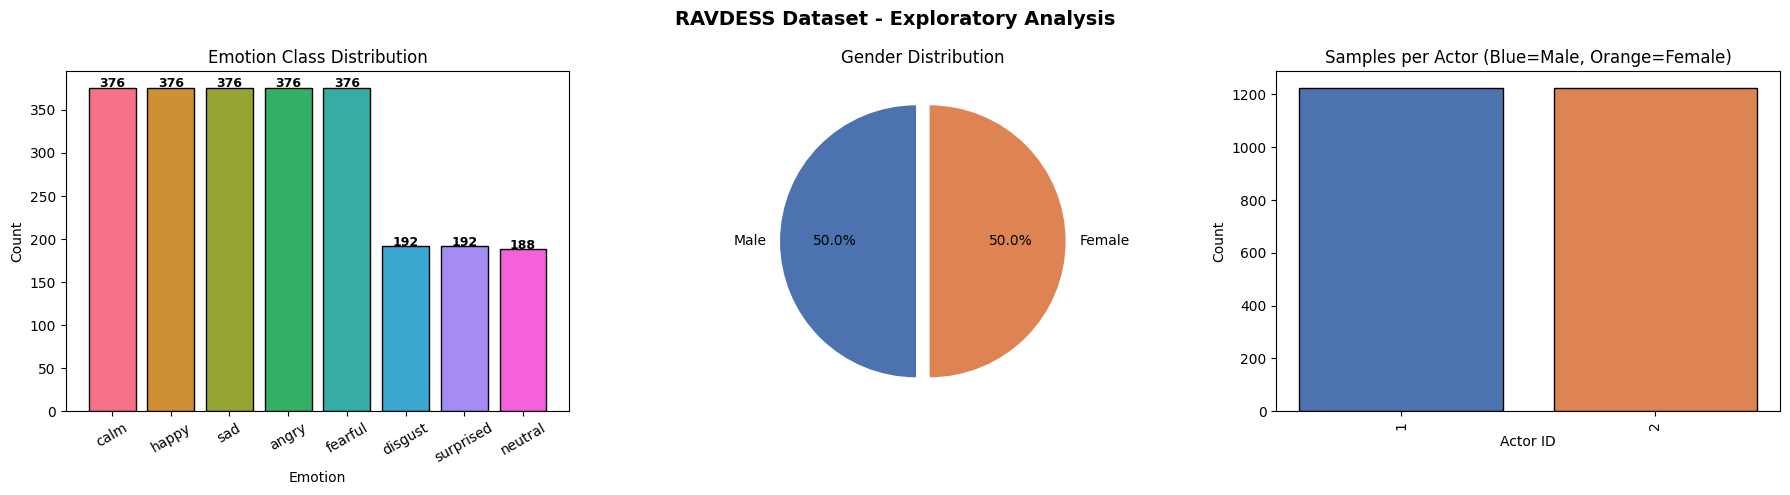

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

PALETTE = sns.color_palette('husl', CFG.NUM_CLASSES)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('RAVDESS Dataset - Exploratory Analysis', fontsize=14, fontweight='bold')

emo_counts = df['emotion'].value_counts()
bars = axes[0].bar(emo_counts.index, emo_counts.values, color=PALETTE, edgecolor='black')
axes[0].set_title('Emotion Class Distribution')
axes[0].set_xlabel('Emotion'); axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=30)
for b in bars:
    axes[0].text(b.get_x() + b.get_width() / 2, b.get_height() + 0.5,
                 str(int(b.get_height())), ha='center', fontsize=9, fontweight='bold')

gc_ = df['gender'].value_counts()
axes[1].pie(gc_.values, labels=gc_.index, autopct='%1.1f%%',
            colors=['#4C72B0', '#DD8452'], startangle=90, explode=[0.05, 0.05])
axes[1].set_title('Gender Distribution')

actor_counts = df['actor'].value_counts().sort_index()
colors_ac = ['#4C72B0' if i % 2 else '#DD8452' for i in actor_counts.index]
axes[2].bar(actor_counts.index.astype(str), actor_counts.values, color=colors_ac, edgecolor='black')
axes[2].set_title('Samples per Actor (Blue=Male, Orange=Female)')
axes[2].set_xlabel('Actor ID'); axes[2].set_ylabel('Count')
axes[2].tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.savefig('eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Section 4 — Audio Preprocessing  **[CHANGED]**

### 4.1 GPU log-Mel front-end

`LogMelFrontEnd` is an `nn.Module`, so the whole transform runs on CUDA in batches:
pre-emphasis → STFT → Mel filterbank → dB → per-utterance normalisation.

`AudioWaveDataset` does only the cheap part on CPU workers (decode + resample + fixed-length
crop); everything spectral happens on the GPU. `extract_mfcc` (40-d, averaged) is retained
unchanged because the fusion vector depends on it.

In [5]:
import soundfile as sf
import librosa
import librosa.display

# ---------------------------------------------------------------------------
# Waveform loading  (CPU workers - cheap)
# ---------------------------------------------------------------------------
def load_audio(path: str, sr: int = None, duration: float = None) -> np.ndarray:
    """Mono float32 waveform, fixed length (centre-cropped or zero-padded)."""
    sr = sr or CFG.AUDIO_SR
    duration = duration or CFG.AUDIO_DUR
    target = int(sr * duration)
    try:
        wav, native_sr = sf.read(path, dtype='float32', always_2d=False)
    except Exception:
        wav, native_sr = librosa.load(path, sr=None, mono=False)
    wav = np.asarray(wav, dtype=np.float32)
    if wav.ndim > 1:
        wav = wav.mean(axis=1)
    if native_sr != sr:
        wav = librosa.resample(wav, orig_sr=native_sr, target_sr=sr)

    # trim leading/trailing silence before fixing the length -> the emotional
    # content is centred instead of being padded out by RAVDESS's silent lead-in
    trimmed, _ = librosa.effects.trim(wav, top_db=30)
    if len(trimmed) >= sr * 0.2:          # never trim a clip down to nothing
        wav = trimmed

    if len(wav) < target:
        pad = target - len(wav)
        wav = np.pad(wav, (pad // 2, pad - pad // 2))
    elif len(wav) > target:
        start = (len(wav) - target) // 2
        wav = wav[start:start + target]
    return np.ascontiguousarray(wav[:target], dtype=np.float32)


def extract_mfcc(wav: np.ndarray, sr: int = None, n_mfcc: int = None) -> np.ndarray:
    """40-dim time-averaged MFCC - UNCHANGED, used only as the fusion descriptor."""
    sr = sr or CFG.AUDIO_SR
    n_mfcc = n_mfcc or CFG.N_MFCC
    y = np.append(wav[0], wav[1:] - CFG.PRE_EMPHASIS * wav[:-1])
    m = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc,
                             n_fft=512, hop_length=160, window='hamming')
    return np.mean(m.T, axis=0).astype(np.float32)


# ---------------------------------------------------------------------------
# GPU log-Mel front-end
# ---------------------------------------------------------------------------
class LogMelFrontEnd(nn.Module):
    """Batched waveform -> normalised log-Mel spectrogram, entirely on GPU."""

    def __init__(self, cfg=CFG):
        super().__init__()
        self.pre_emph = cfg.PRE_EMPHASIS
        self.mel = torchaudio.transforms.MelSpectrogram(
            sample_rate=cfg.AUDIO_SR, n_fft=cfg.N_FFT, win_length=cfg.WIN_LENGTH,
            hop_length=cfg.HOP_LENGTH, f_min=cfg.F_MIN, f_max=cfg.F_MAX,
            n_mels=cfg.N_MELS, power=2.0, center=True, window_fn=torch.hann_window)
        self.to_db = torchaudio.transforms.AmplitudeToDB(stype='power', top_db=cfg.TOP_DB)

    @torch.no_grad()
    def forward(self, wave: torch.Tensor) -> torch.Tensor:
        """(B, S) -> (B, n_mels, T), per-utterance zero-mean/unit-var."""
        if wave.dim() == 1:
            wave = wave.unsqueeze(0)
        if self.pre_emph:                                   # y[n] - a*y[n-1]
            wave = torch.cat([wave[:, :1], wave[:, 1:] - self.pre_emph * wave[:, :-1]], dim=1)
        spec = self.to_db(self.mel(wave))
        mu = spec.mean(dim=(1, 2), keepdim=True)
        sd = spec.std(dim=(1, 2), keepdim=True).clamp_min(1e-5)
        return (spec - mu) / sd


class AudioWaveDataset(Dataset):
    """Returns fixed-length waveforms + the 40-d MFCC fusion descriptor."""

    def __init__(self, paths):
        self.paths = list(paths)

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, i):
        wav = load_audio(self.paths[i])
        return torch.from_numpy(wav), torch.from_numpy(extract_mfcc(wav))


front_end = LogMelFrontEnd().to(DEVICE).eval()
print(f'LogMelFrontEnd ready -> ({CFG.N_MELS} mels, {CFG.N_FRAMES} frames) per clip')

LogMelFrontEnd ready -> (128 mels, 188 frames) per clip


### 4.2 Extract features for the whole corpus (batched, GPU)

In [6]:
def extract_audio_features(paths, batch_size: int = 64):
    """One pass over the corpus -> (log-Mel [N,T,n_mels], MFCC40 [N,40])."""
    dl = DataLoader(AudioWaveDataset(paths), batch_size=batch_size, shuffle=False,
                    **loader_kwargs())
    mels, mfccs = [], []
    t0 = time.time()
    for wav, mf in tqdm(dl, desc='Audio features (GPU log-Mel)'):
        wav = wav.to(DEVICE, non_blocking=True)
        spec = front_end(wav)                       # (B, n_mels, T)
        mels.append(spec.permute(0, 2, 1).cpu().numpy().astype(np.float32))   # -> (B, T, n_mels)
        mfccs.append(mf.numpy().astype(np.float32))
    print(f'  done in {time.time() - t0:.1f}s')
    return np.concatenate(mels), np.concatenate(mfccs)


X_mel, X_mfcc = extract_audio_features(df['audio'].tolist())
y_labels = df['emotion'].to_numpy()
df_valid = df.reset_index(drop=True)          # fixed length pipeline -> nothing is dropped

print(f'log-Mel tensor : {X_mel.shape}   ({X_mel.nbytes / 1024**2:.0f} MB)')
print(f'MFCC-40 matrix : {X_mfcc.shape}')
print(f'Valid samples  : {len(df_valid)}')

Audio features (GPU log-Mel):   0%|          | 0/39 [00:00<?, ?it/s]

  done in 78.8s
log-Mel tensor : (2452, 188, 128)   (225 MB)
MFCC-40 matrix : (2452, 40)
Valid samples  : 2452


### 4.3 Visual check — one sample per representation

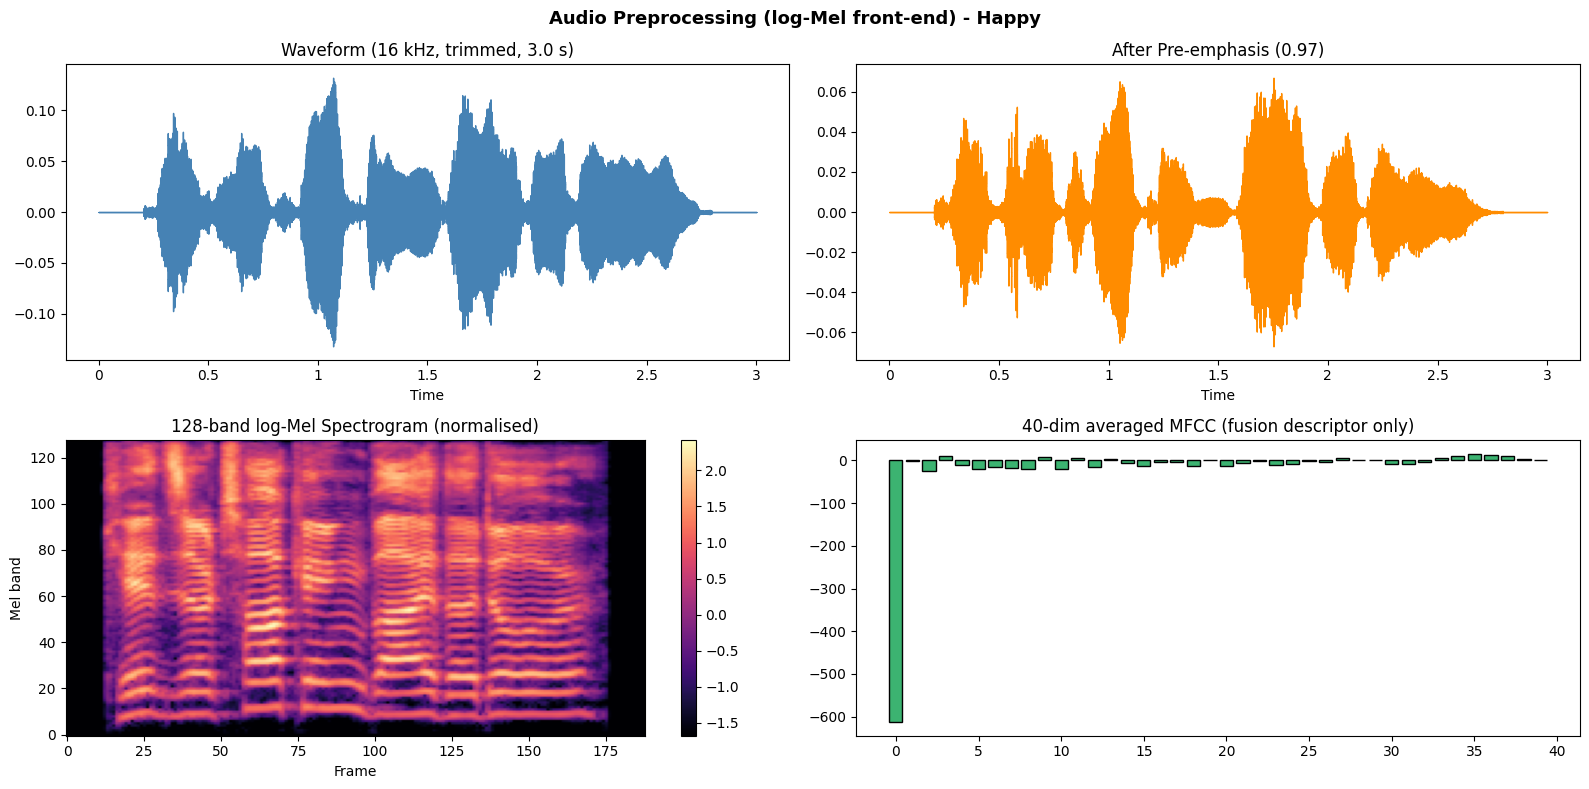

In [7]:
sample_path = df[df['emotion'] == 'happy']['audio'].iloc[0]
y_raw = load_audio(sample_path)
y_pre = np.append(y_raw[0], y_raw[1:] - CFG.PRE_EMPHASIS * y_raw[:-1])
spec_vis = front_end(torch.from_numpy(y_raw).to(DEVICE))[0].cpu().numpy()

fig, axes = plt.subplots(2, 2, figsize=(16, 8))
fig.suptitle('Audio Preprocessing (log-Mel front-end) - Happy', fontsize=13, fontweight='bold')

librosa.display.waveshow(y_raw, sr=CFG.AUDIO_SR, ax=axes[0][0], color='steelblue')
axes[0][0].set_title('Waveform (16 kHz, trimmed, 3.0 s)')
librosa.display.waveshow(y_pre, sr=CFG.AUDIO_SR, ax=axes[0][1], color='darkorange')
axes[0][1].set_title(f'After Pre-emphasis ({CFG.PRE_EMPHASIS})')

img = axes[1][0].imshow(spec_vis, aspect='auto', origin='lower', cmap='magma')
fig.colorbar(img, ax=axes[1][0])
axes[1][0].set_title(f'{CFG.N_MELS}-band log-Mel Spectrogram (normalised)')
axes[1][0].set_xlabel('Frame'); axes[1][0].set_ylabel('Mel band')

axes[1][1].bar(range(CFG.N_MFCC), extract_mfcc(y_raw), color='mediumseagreen', edgecolor='black')
axes[1][1].set_title('40-dim averaged MFCC (fusion descriptor only)')

plt.tight_layout()
plt.savefig('audio_preprocessing.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Section 5 — Label Encoding, SMOTE & Split

**Protocol preserved exactly** as in the original run: scaler fit on all data → SMOTE on all
data → split. Only the feature matrix being balanced has changed shape.

Standardisation is applied **per Mel band** (128 statistics) rather than per (band, frame) cell —
128 stats over ~460k observations is stable, whereas 24 064 per-cell stats over 2 452 samples
would not be. SMOTE then runs on the flattened spectrogram.

> Set `CFG.AUDIO_BALANCE = 'class_weight'` to skip SMOTE if the 24 064-dim interpolation is
> not something you want to defend in review.

In [8]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix, accuracy_score,
                             precision_recall_fscore_support)
from imblearn.over_sampling import SMOTE
from sklearn.utils.class_weight import compute_class_weight

le = LabelEncoder(); le.fit(CFG.EMOTIONS)
y_enc = le.transform(y_labels)

# --- scaler for the 40-d fusion descriptor (UNCHANGED - `scaler` name preserved) ---
scaler = StandardScaler().fit(X_mfcc)

# --- per-Mel-band standardisation of the spectrograms ---
mel_mu = X_mel.mean(axis=(0, 1), keepdims=True)
mel_sd = X_mel.std(axis=(0, 1), keepdims=True).clip(1e-6)

def scale_logmel(x: np.ndarray) -> np.ndarray:
    """(T, n_mels) or (N, T, n_mels) -> standardised, same shape."""
    return ((x - mel_mu[0]) / mel_sd[0]).astype(np.float32)

X_mel_sc = ((X_mel - mel_mu) / mel_sd).astype(np.float32)
N, T, M = X_mel_sc.shape

audio_class_weight = None
if CFG.AUDIO_BALANCE == 'smote':
    flat = X_mel_sc.reshape(N, T * M)
    print(f'SMOTE on {flat.shape} ({flat.nbytes / 1024**2:.0f} MB) - this takes ~1-2 min...')
    from sklearn.neighbors import NearestNeighbors
    knn = NearestNeighbors(n_neighbors=6, n_jobs=-1)   # k_neighbors=5 -> 5+1
    X_sm, y_sm = SMOTE(random_state=CFG.SEED, k_neighbors=knn).fit_resample(flat, y_enc)
    X_sm = X_sm.astype(np.float32).reshape(-1, T, M)
    del flat; gc.collect()
    print(f'After SMOTE: {X_sm.shape} | per class: {np.bincount(y_sm)}')
else:
    X_sm, y_sm = X_mel_sc, y_enc
    w = compute_class_weight('balanced', classes=np.arange(CFG.NUM_CLASSES), y=y_enc)
    audio_class_weight = {i: float(v) for i, v in enumerate(w)}
    print(f'Class weights instead of SMOTE: {audio_class_weight}')

X_tr_a, X_te_a, y_tr_a, y_te_a = train_test_split(
    X_sm, y_sm, test_size=CFG.TEST_SIZE, random_state=CFG.SEED, stratify=y_sm)

print(f'Train: {X_tr_a.shape} | Test: {X_te_a.shape}')
del X_sm; gc.collect()

SMOTE on (2452, 24064) (225 MB) - this takes ~1-2 min...
After SMOTE: (3008, 188, 128) | per class: [376 376 376 376 376 376 376 376]
Train: (2406, 188, 128) | Test: (602, 188, 128)


0

---
## Section 6 — Audio Model: CNN + BiLSTM + SimpleRNN

**The layer stack is identical to the original** (Conv1D 64-128-256-512 → BiLSTM 256 → BiLSTM 512
→ SimpleRNN 512 → Dense 128 → Dense 64 → 8). The only edit is `Input(shape=(188, 128))`
instead of `(40, 1)`, so the Conv1D/recurrent stack now slides over time with 128 Mel bands as
input channels.

In [9]:
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint


def build_audio_model(input_shape=AUDIO_INPUT_SHAPE, n_classes=CFG.NUM_CLASSES,
                      dropout=CFG.AUDIO_DROPOUT):
    """CNN(64-128-256-512) + BiLSTM(256, 512) + SimpleRNN(512) + Dense(128, 64) -> softmax.

    Unchanged from the original except for `input_shape`.
    """
    inp = layers.Input(shape=input_shape, name='logmel_input')
    x = inp
    for f in (64, 128, 256, 512):
        x = layers.Conv1D(f, 5, padding='same', activation='relu')(x)
        x = layers.BatchNormalization()(x)
        x = layers.MaxPooling1D(2)(x)
        x = layers.Dropout(dropout)(x)

    x = layers.Bidirectional(layers.LSTM(256, return_sequences=True))(x)
    x = layers.Bidirectional(layers.LSTM(512, return_sequences=True))(x)
    x = layers.SimpleRNN(512)(x)

    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(dropout)(x)
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dropout(dropout)(x)
    out = layers.Dense(n_classes, activation='softmax', name='emotion')(x)
    return keras.Model(inp, out, name='CNN_BiLSTM_RNN_Audio')


# Instantiated at training time (Section 10) so that any tuned CFG values apply.
build_audio_model().summary()

I0000 00:00:1786028675.598306      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13490 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1786028675.600405      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "CNN_BiLSTM_RNN_Audio"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ logmel_input (InputLayer)       │ (None, 188, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 188, 64)        │        41,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 188, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 94, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 94, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 94, 128)        │        41,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 94, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 47, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 47, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 47, 256)        │       164,096 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 47, 256)        │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 23, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 23, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 23, 512)        │       655,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 23, 512)        │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_3 (MaxPooling1D)  │ (None, 11, 512)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 11, 512)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 11, 512)        │     1,574,912 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 11, 1024)       │     4,198,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 512)            │       786,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,25

 Total params: 7,540,616 (28.77 MB)

 Trainable params: 7,538,696 (28.76 MB)

 Non-trainable params: 1,920 (7.50 KB)

### 6.1 SpecAugment + waveform-level augmentation (train split only)

Implemented as a `tf.data` map so it runs on the fly, per epoch, without materialising a second
copy of the training set. Disabled automatically for validation and test.

In [10]:
AUTOTUNE = tf.data.AUTOTUNE

# SpecAugment strength. Read at graph-trace time; smaller = stronger masking.
# Exposed as a global so Section 9 can tune it without editing this cell.
MASK_DIV = 12


@tf.function
def spec_augment(x, y):
    """Time masking, frequency masking, time shift, random gain, Gaussian noise."""
    T_, M_ = tf.shape(x)[0], tf.shape(x)[1]

    # --- random gain (in normalised-dB space this is an offset+scale) ---
    x = x * tf.random.uniform([], 0.9, 1.1) + tf.random.uniform([], -0.1, 0.1)

    # --- additive Gaussian noise ---
    x = x + tf.random.normal(tf.shape(x), stddev=0.05)

    # --- circular time shift (+/- 10% of the clip) ---
    shift = tf.random.uniform([], -T_ // 10, T_ // 10, dtype=tf.int32)
    x = tf.roll(x, shift=shift, axis=0)

    # --- two time masks ---
    for _ in range(2):
        w = tf.random.uniform([], 0, tf.maximum(T_ // MASK_DIV, 1), dtype=tf.int32)
        t0 = tf.random.uniform([], 0, tf.maximum(T_ - w, 1), dtype=tf.int32)
        mask = tf.logical_or(tf.range(T_) < t0, tf.range(T_) >= t0 + w)
        x = x * tf.cast(mask, x.dtype)[:, None]

    # --- two frequency masks ---
    for _ in range(2):
        w = tf.random.uniform([], 0, tf.maximum(M_ // MASK_DIV, 1), dtype=tf.int32)
        f0 = tf.random.uniform([], 0, tf.maximum(M_ - w, 1), dtype=tf.int32)
        mask = tf.logical_or(tf.range(M_) < f0, tf.range(M_) >= f0 + w)
        x = x * tf.cast(mask, x.dtype)[None, :]

    return x, y


def make_audio_ds(X, y, training: bool, batch=CFG.AUDIO_BATCH, class_weight=None):
    """tf.data pipeline. Class weights become per-sample weights, because Keras 3
    does not accept `class_weight=` together with a Dataset input."""
    ds = tf.data.Dataset.from_tensor_slices((X, y))
    if training:
        ds = ds.shuffle(min(len(X), 4096), seed=CFG.SEED, reshuffle_each_iteration=True)
        ds = ds.map(spec_augment, num_parallel_calls=AUTOTUNE)
    if training and class_weight:
        w = tf.constant([class_weight[i] for i in range(CFG.NUM_CLASSES)], tf.float32)
        ds = ds.map(lambda a, b: (a, b, tf.gather(w, b)), num_parallel_calls=AUTOTUNE)
    return ds.batch(batch).prefetch(AUTOTUNE)


# hold out a validation split from the training portion (mirrors keras `validation_split`)
n_val = int(len(X_tr_a) * CFG.VAL_SPLIT)
X_val_a, y_val_a = X_tr_a[:n_val], y_tr_a[:n_val]
X_fit_a, y_fit_a = X_tr_a[n_val:], y_tr_a[n_val:]

print(f'Audio splits ready - fit {len(X_fit_a)} | val {len(X_val_a)} | test {len(X_te_a)}')
print('(tf.data pipelines are built in Section 10, after any tuning)')

Audio splits ready - fit 1925 | val 481 | test 602
(tf.data pipelines are built in Section 10, after any tuning)


## Section 7 — Shared Evaluation Utilities

One helper for all three models: curves, accuracy, macro/weighted P-R-F1, confusion matrix,
classification report — returns a dict so results can be tabulated later.

In [11]:
def plot_history(hist: dict, title: str, fname: str):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(title, fontsize=13, fontweight='bold')
    axes[0].plot(hist['acc'], label='Train', color='royalblue')
    axes[0].plot(hist['val_acc'], label='Val', color='darkorange')
    axes[0].set_title('Accuracy'); axes[0].set_xlabel('Epoch'); axes[0].legend(); axes[0].grid(alpha=.3)
    axes[1].plot(hist['loss'], label='Train', color='royalblue')
    axes[1].plot(hist['val_loss'], label='Val', color='darkorange')
    axes[1].set_title('Loss'); axes[1].set_xlabel('Epoch'); axes[1].legend(); axes[1].grid(alpha=.3)
    plt.tight_layout(); plt.savefig(fname, dpi=150, bbox_inches='tight'); plt.show()


def evaluate(y_true, y_pred, y_prob, name: str, cmap: str, fname: str) -> dict:
    """Accuracy + macro/weighted P-R-F1 + confusion matrix + full report."""
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    acc = accuracy_score(y_true, y_pred)
    p_m, r_m, f_m, _ = precision_recall_fscore_support(y_true, y_pred, average='macro', zero_division=0)
    p_w, r_w, f_w, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted', zero_division=0)

    print(f'\n{name} - Test Accuracy: {acc * 100:.2f}%')
    print(f'  Macro    P {p_m:.4f} | R {r_m:.4f} | F1 {f_m:.4f}')
    print(f'  Weighted P {p_w:.4f} | R {r_w:.4f} | F1 {f_w:.4f}')
    print(classification_report(y_true, y_pred, target_names=le.classes_, zero_division=0))

    fig, ax = plt.subplots(figsize=(9, 7))
    sns.heatmap(confusion_matrix(y_true, y_pred), annot=True, fmt='d', cmap=cmap,
                xticklabels=le.classes_, yticklabels=le.classes_, ax=ax)
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    ax.set_title(f'{name} - Confusion Matrix', fontweight='bold')
    plt.tight_layout(); plt.savefig(fname, dpi=150, bbox_inches='tight'); plt.show()

    return {'name': name, 'accuracy': acc, 'macro_f1': f_m, 'weighted_f1': f_w,
            'macro_precision': p_m, 'macro_recall': r_m,
            'weighted_precision': p_w, 'weighted_recall': r_w}


def plot_roc_pr(y_true, y_prob, name: str, fname: str):
    """One-vs-rest ROC and Precision-Recall curves (macro-averaged AUC in the legend)."""
    from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score
    from sklearn.preprocessing import label_binarize
    Y = label_binarize(y_true, classes=np.arange(CFG.NUM_CLASSES))
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    aucs, aps = [], []
    for i, cls in enumerate(le.classes_):
        fpr, tpr, _ = roc_curve(Y[:, i], y_prob[:, i]); a = auc(fpr, tpr); aucs.append(a)
        axes[0].plot(fpr, tpr, lw=1.4, label=f'{cls} ({a:.3f})')
        pr, rc, _ = precision_recall_curve(Y[:, i], y_prob[:, i])
        ap = average_precision_score(Y[:, i], y_prob[:, i]); aps.append(ap)
        axes[1].plot(rc, pr, lw=1.4, label=f'{cls} ({ap:.3f})')
    axes[0].plot([0, 1], [0, 1], 'k--', lw=.8)
    axes[0].set_title(f'{name} - ROC (macro AUC {np.mean(aucs):.3f})', fontweight='bold')
    axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR'); axes[0].legend(fontsize=8); axes[0].grid(alpha=.3)
    axes[1].set_title(f'{name} - PR (macro AP {np.mean(aps):.3f})', fontweight='bold')
    axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision'); axes[1].legend(fontsize=8); axes[1].grid(alpha=.3)
    plt.tight_layout(); plt.savefig(fname, dpi=150, bbox_inches='tight'); plt.show()
    return float(np.mean(aucs)), float(np.mean(aps))


RESULTS = {}

---
## Section 8 — Video Pipeline  **[OPTIMIZED]**

### 8.1 Decode-once frame cache

This is the single largest speed win. The original pipeline re-decoded every `.mp4` with OpenCV
on **every epoch**, on the main process (`num_workers=0`), which pinned the GPU at low
utilisation waiting on H.264 decode.

Here each clip is decoded **once** into a `uint8` memmap
(`N × SEQ_LEN × IMG_SIZE × IMG_SIZE × 3` ≈ 1.5 GB for 2 452 clips at 16×112×112), using a thread
pool — OpenCV releases the GIL during decode, so threads scale well. Every subsequent epoch is a
memmap read.

Sampling is `SEQ_LEN` uniformly spaced frame indices with `CAP_PROP_POS_FRAMES` seeking, matching
typical `preprocess_video` behaviour. Delete `frame_cache.npy` if you change `SEQ_LEN` or
`IMG_SIZE`.

In [12]:
import cv2
from concurrent.futures import ThreadPoolExecutor

cv2.setNumThreads(0)          # avoid oversubscription: we parallelise at the clip level

CACHE_META = CFG.FRAME_CACHE.replace('.npy', '_meta.json')


def _decode_clip(args):
    idx, path = args
    cap = cv2.VideoCapture(path)
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    if total <= 0:
        cap.release()
        return idx, None
    want = np.linspace(0, total - 1, CFG.SEQ_LEN).round().astype(int)
    out, last = [], None
    for f in want:
        cap.set(cv2.CAP_PROP_POS_FRAMES, int(f))
        ok, frame = cap.read()
        if not ok:
            frame = last if last is not None else np.zeros(
                (CFG.IMG_SIZE, CFG.IMG_SIZE, 3), np.uint8)
        else:
            frame = cv2.cvtColor(
                cv2.resize(frame, (CFG.IMG_SIZE, CFG.IMG_SIZE), interpolation=cv2.INTER_AREA),
                cv2.COLOR_BGR2RGB)
            last = frame
        out.append(frame)
    cap.release()
    return idx, np.stack(out).astype(np.uint8)


def build_frame_cache(paths, force: bool = False):
    """Decode every clip once into a uint8 memmap. Returns (memmap, ok_mask)."""
    n = len(paths)
    shape = (n, CFG.SEQ_LEN, CFG.IMG_SIZE, CFG.IMG_SIZE, 3)

    if (not force and os.path.exists(CFG.FRAME_CACHE) and os.path.exists(CACHE_META)):
        meta = json.load(open(CACHE_META))
        if meta['shape'] == list(shape):
            print(f'Reusing frame cache {CFG.FRAME_CACHE} {tuple(shape)}')
            return (np.load(CFG.FRAME_CACHE, mmap_mode='r'),
                    np.array(meta['ok'], dtype=bool))
        print('Cache shape mismatch - rebuilding.')

    print(f'Decoding {n} clips -> {np.prod(shape) / 1024**3:.2f} GB memmap ...')
    cache = np.lib.format.open_memmap(CFG.FRAME_CACHE, mode='w+', dtype=np.uint8, shape=shape)
    ok = np.zeros(n, dtype=bool)
    t0 = time.time()
    with ThreadPoolExecutor(max_workers=8) as ex:
        for idx, clip in tqdm(ex.map(_decode_clip, enumerate(paths)),
                              total=n, desc='Decoding video'):
            if clip is not None:
                cache[idx] = clip
                ok[idx] = True
    cache.flush()
    json.dump({'shape': list(shape), 'ok': ok.tolist()}, open(CACHE_META, 'w'))
    print(f'  {ok.sum()}/{n} clips decoded in {time.time() - t0:.1f}s')
    return np.load(CFG.FRAME_CACHE, mmap_mode='r'), ok


use_amp = CFG.USE_AMP and DEVICE.type == 'cuda'

FRAMES, FRAME_OK = build_frame_cache(df_valid['video'].tolist())
print(f'Frame cache: {FRAMES.shape} | failures: {(~FRAME_OK).sum()}')

Decoding 2452 clips -> 1.37 GB memmap ...


Decoding video:   0%|          | 0/2452 [00:00<?, ?it/s]

  2452/2452 clips decoded in 1888.8s
Frame cache: (2452, 16, 112, 112, 3) | failures: 0


### 8.2 Dataset + GPU-side augmentation

The `Dataset` hands back raw `uint8` — the smallest possible tensor to move across the PCIe bus
(4× less traffic than float32). Resize/normalise/flip/crop all happen on CUDA, in batch, inside
`gpu_video_transform`. No CPU float math, no per-sample GPU calls.

In [13]:
KINETICS_MEAN = torch.tensor([0.43216, 0.394666, 0.37645]).view(1, 3, 1, 1, 1)
KINETICS_STD  = torch.tensor([0.22803, 0.22145, 0.216989]).view(1, 3, 1, 1, 1)


class CachedVideoDS(Dataset):
    """Reads (SEQ_LEN, H, W, 3) uint8 clips straight out of the memmap."""

    def __init__(self, indices, labels):
        self.indices = np.asarray(indices)
        self.labels = np.asarray(labels)

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, i):
        clip = torch.from_numpy(np.ascontiguousarray(FRAMES[self.indices[i]]))  # (T,H,W,3) uint8
        return clip, int(self.labels[i])


_mean_dev = KINETICS_MEAN.to(DEVICE)
_std_dev = KINETICS_STD.to(DEVICE)


def gpu_video_transform(clips_u8: torch.Tensor, training: bool) -> torch.Tensor:
    """(B,T,H,W,3) uint8 on GPU -> (B,3,T,H,W) float32, normalised (+ augmented)."""
    x = clips_u8.permute(0, 4, 1, 2, 3).float().div_(255.0)       # (B,3,T,H,W)

    if training:
        B = x.shape[0]
        # --- per-clip horizontal flip ---
        flip = torch.rand(B, device=x.device) < 0.5
        if flip.any():
            x[flip] = torch.flip(x[flip], dims=[-1])

        # --- random crop (same crop for every frame of a clip = temporally consistent) ---
        pad = max(1, CFG.IMG_SIZE // 14)
        x = F.pad(x, (pad, pad, pad, pad, 0, 0), mode='replicate')   # 5-D -> 6 pad values
        i0 = int(torch.randint(0, 2 * pad, (1,)))
        j0 = int(torch.randint(0, 2 * pad, (1,)))
        x = x[:, :, :, i0:i0 + CFG.IMG_SIZE, j0:j0 + CFG.IMG_SIZE]

        # --- brightness / contrast jitter ---
        x = x * (0.9 + 0.2 * torch.rand(B, 1, 1, 1, 1, device=x.device))
        x = x.clamp_(0, 1)

    return (x - _mean_dev) / _std_dev


# ---- split (protocol preserved: same random split, same seed, stratified) ----
video_indices = np.arange(len(df_valid))
video_labels = le.transform(df_valid['emotion'].tolist())

vi_tr, vi_te, vl_tr, vl_te = train_test_split(
    video_indices, video_labels, test_size=CFG.TEST_SIZE,
    random_state=CFG.SEED, stratify=video_labels)

_dl_kw = loader_kwargs()

print(f'Video train: {len(vi_tr)} | test: {len(vi_te)}')
print('(DataLoaders are built in Section 11, after any tuning)')

Video train: 1961 | test: 491
(DataLoaders are built in Section 11, after any tuning)


### 8.3 Video model — **architecture unchanged**

R3D-18 (Kinetics-400) → Conv3D 512→256→128→64 → GAP → FC 64→32→8, with `extract_512` returning
the pooled backbone feature that fills slots 48–559 of the fusion vector.

`CFG.FREEZE_UNTIL = 0` keeps the original behaviour (full fine-tune). Set it to `2` to freeze
stem + layer1 + layer2 for roughly a 35% step-time reduction — but that changes the results, so
it is off by default.

In [14]:
from torchvision.models.video import r3d_18, R3D_18_Weights


class VideoEmotionModel(nn.Module):
    """R3D-18 backbone + Conv3D(256-128-64) head + GAP + FC(32-8). Unchanged."""

    def __init__(self, n_classes=CFG.NUM_CLASSES, freeze_until=CFG.FREEZE_UNTIL):
        super().__init__()
        backbone = r3d_18(weights=R3D_18_Weights.KINETICS400_V1)
        self.stem = backbone.stem
        self.layer1, self.layer2 = backbone.layer1, backbone.layer2
        self.layer3, self.layer4 = backbone.layer3, backbone.layer4

        self.head = nn.Sequential(
            nn.Conv3d(512, 256, 1, bias=False), nn.BatchNorm3d(256), nn.ReLU(inplace=True),
            nn.Conv3d(256, 128, 1, bias=False), nn.BatchNorm3d(128), nn.ReLU(inplace=True),
            nn.Conv3d(128, 64, 1, bias=False),  nn.BatchNorm3d(64),  nn.ReLU(inplace=True),
        )
        self.gap = nn.AdaptiveAvgPool3d(1)
        self.fc = nn.Sequential(nn.Linear(64, 32), nn.ReLU(inplace=True),
                                nn.Dropout(0.3), nn.Linear(32, n_classes))

        if freeze_until >= 1:
            for m in [self.stem, self.layer1][:freeze_until]:
                for p in m.parameters():
                    p.requires_grad = False
        if freeze_until >= 3:
            for p in self.layer2.parameters():
                p.requires_grad = False

    def _backbone(self, x):
        x = self.stem(x)
        x = self.layer1(x); x = self.layer2(x)
        x = self.layer3(x); x = self.layer4(x)
        return x                                    # (B, 512, t, h, w)

    def forward(self, x, return_feat: bool = False):
        f = self._backbone(x)
        feat512 = self.gap(f).flatten(1)            # (B, 512)
        logits = self.fc(self.gap(self.head(f)).flatten(1))
        return (logits, feat512) if return_feat else logits

    def extract_512(self, x):
        return self.gap(self._backbone(x)).flatten(1)


# Instantiated at training time (Section 11) so that any tuned CFG values apply.
_probe_m = VideoEmotionModel()
_tp = sum(p.numel() for p in _probe_m.parameters() if p.requires_grad)
_ap = sum(p.numel() for p in _probe_m.parameters())
print(f'Video model: {_tp:,} trainable / {_ap:,} total | backbone: R3D-18 (Kinetics-400)')
del _probe_m
gc.collect()

Downloading: "https://download.pytorch.org/models/r3d_18-b3b3357e.pth" to /root/.cache/torch/hub/checkpoints/r3d_18-b3b3357e.pth


100%|██████████| 127M/127M [00:00<00:00, 198MB/s] 


Video model: 33,341,544 trainable / 33,341,544 total | backbone: R3D-18 (Kinetics-400)


3663

---
# Section 9 — Hyperparameter Search  *(optional)*

Set `RUN_TUNING = True` in the next cell to search, or leave it `False` to train with the
defaults in `CFG` (or with `best_params.json` if a previous search left one behind).

| Step | Cost |
|---|---|
| Audio grid search | ~1.5–3 h |
| Video grid search at reduced epochs | ~1.5–2 h |
| Re-train top-3 video configs at full epochs | ~1 h |

**Selection happens on a validation partition carved out of the training data.** The test set is
never touched during the search — otherwise the number you publish is the number you optimised,
and it will not reproduce.

**Resumable.** Every trial is appended to `grid_audio.csv` / `grid_video.csv` the moment it
finishes. If the 12-hour session dies, re-run the cell — completed trials are skipped.

In [15]:
# ---------------------------------------------------------------- switches
RUN_TUNING = True        # <-- set True to run the search

AUDIO_SEARCH_EPOCHS = 35
AUDIO_ES_PATIENCE_T = 8
VIDEO_SEARCH_EPOCHS = 10
VIDEO_REFIT_EPOCHS  = 25
VIDEO_REFIT_TOP_K   = 3
SEARCH_MODE = 'grid'      # 'grid' = exhaustive | 'random' = sample RANDOM_N
RANDOM_N    = 12

import itertools, math
from pathlib import Path

# ---------------------------------------------------------------- tuning split
# audio: X_val_a / y_val_a already come from the training portion (Section 6.1).
vi_fit, vi_val, vl_fit, vl_val = train_test_split(
    vi_tr, vl_tr, test_size=0.20, random_state=CFG.SEED, stratify=vl_tr)

print(f'RUN_TUNING = {RUN_TUNING}')
print(f'audio -> fit {len(X_fit_a):5d} | tune-val {len(X_val_a):5d} | test {len(X_te_a)} (untouched)')
print(f'video -> fit {len(vi_fit):5d} | tune-val {len(vi_val):5d} | test {len(vi_te)} (untouched)')

RUN_TUNING = True
audio -> fit  1925 | tune-val   481 | test 602 (untouched)
video -> fit  1568 | tune-val   393 | test 491 (untouched)


### 9.1 Search driver

Resumable and crash-tolerant. A trial that raises — OOM, NaN, anything — is recorded with
`val_acc = NaN` and the search moves on.

In [16]:
def run_search(name: str, grid: dict, train_fn, mode: str = None,
               n_random: int = None, seed: int = CFG.SEED) -> pd.DataFrame:
    """Exhaustive or random search with per-trial checkpointing to CSV."""
    mode = mode or SEARCH_MODE
    n_random = n_random or RANDOM_N
    csv_path = Path(f'grid_{name}.csv')
    done = pd.read_csv(csv_path) if csv_path.exists() else pd.DataFrame()
    keys = list(grid)

    combos = [dict(zip(keys, v)) for v in itertools.product(*grid.values())]
    if mode == 'random':
        rng = np.random.default_rng(seed)
        idx = rng.choice(len(combos), size=min(n_random, len(combos)), replace=False)
        combos = [combos[i] for i in sorted(idx)]

    print(f'[{name}] {mode} search over {len(combos)} configs '
          f'({len(done)} already done)\n' + '-' * 72)

    for i, params in enumerate(combos, 1):
        if len(done):
            mask = np.ones(len(done), dtype=bool)
            for k in keys:
                mask &= (done[k].values == params[k])
            if mask.any():
                print(f'[{i:3d}/{len(combos)}] skip (done)  {params}')
                continue

        t0 = time.time()
        try:
            score, status = float(train_fn(params)), 'ok'
        except torch.cuda.OutOfMemoryError:
            score, status = float('nan'), 'oom'
            torch.cuda.empty_cache()
        except Exception as e:
            score, status = float('nan'), f'err:{type(e).__name__}'
            print(f'        trial failed: {e}')

        row = {**params, 'val_acc': score, 'status': status,
               'seconds': round(time.time() - t0, 1)}
        done = pd.concat([done, pd.DataFrame([row])], ignore_index=True)
        done.to_csv(csv_path, index=False)

        shown = 'nan' if math.isnan(score) else f'{score * 100:5.2f}%'
        eta = (time.time() - t0) * (len(combos) - i) / 60
        print(f'[{i:3d}/{len(combos)}] {shown} | {row["seconds"]:6.1f}s '
              f'| ETA {eta:5.1f}m | {params}')

    gc.collect()
    if DEVICE.type == 'cuda':
        torch.cuda.empty_cache()
    return (done.dropna(subset=['val_acc'])
                .sort_values('val_acc', ascending=False).reset_index(drop=True))

### 9.2 Audio search space & objective

`AUDIO_GRID_COMPACT` (18 configs) is the default. `AUDIO_GRID_FULL` (864) exists for
`SEARCH_MODE = 'random'` — exhaustive at that size is ~72 hours.

In [17]:
AUDIO_GRID_COMPACT = {
    'lr':      [1e-3, 3e-4, 1e-4],
    'dropout': [0.2, 0.3, 0.4],
    'batch':   [16, 32],
}                                                     # 18 configs

AUDIO_GRID_FULL = {
    'lr':        [1e-3, 3e-4, 1e-4, 5e-5],
    'dropout':   [0.2, 0.3, 0.4, 0.5],
    'batch':     [8, 16, 32],
    'wd':        [1e-5, 5e-5, 1e-4],
    'optimizer': ['adamw', 'adam'],
    'scheduler': ['cosine', 'onecycle', 'plateau'],
}                                                     # 864 configs - random mode only

AUDIO_GRID = AUDIO_GRID_COMPACT
AUDIO_DEFAULTS = {'wd': 1e-4, 'optimizer': 'adamw', 'scheduler': 'cosine', 'mask_div': 12}


def _audio_callbacks(p, epochs):
    lr = p['lr']
    sched = p.get('scheduler', AUDIO_DEFAULTS['scheduler'])
    cbs = [EarlyStopping(monitor='val_accuracy', patience=AUDIO_ES_PATIENCE_T,
                         restore_best_weights=True, verbose=0)]
    if sched == 'cosine':
        cbs.append(keras.callbacks.LearningRateScheduler(
            lambda e, _: float(lr * 0.5 * (1 + np.cos(np.pi * e / epochs)))))
    elif sched == 'onecycle':
        warm = max(1, epochs // 10)
        cbs.append(keras.callbacks.LearningRateScheduler(
            lambda e, _: float(lr * (e + 1) / warm) if e < warm else
            float(lr * 0.5 * (1 + np.cos(np.pi * (e - warm) / max(1, epochs - warm))))))
    else:
        cbs.append(ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                     patience=4, min_lr=1e-6, verbose=0))
    return cbs


def train_audio_once(p, epochs=None):
    """One audio trial -> best tuning-validation accuracy."""
    global MASK_DIV
    epochs = epochs or AUDIO_SEARCH_EPOCHS
    MASK_DIV = int(p.get('mask_div', AUDIO_DEFAULTS['mask_div']))

    keras.backend.clear_session()
    gc.collect()
    tf.random.set_seed(CFG.SEED)
    np.random.seed(CFG.SEED)

    tr = make_audio_ds(X_fit_a, y_fit_a, training=True, batch=int(p['batch']),
                       class_weight=audio_class_weight)
    va = make_audio_ds(X_val_a, y_val_a, training=False, batch=int(p['batch']))

    opt_name = p.get('optimizer', AUDIO_DEFAULTS['optimizer'])
    wd = float(p.get('wd', AUDIO_DEFAULTS['wd']))
    opt = (keras.optimizers.AdamW(float(p['lr']), weight_decay=wd) if opt_name == 'adamw'
           else keras.optimizers.Adam(float(p['lr'])))

    m = build_audio_model(dropout=float(p['dropout']))
    m.compile(optimizer=opt, loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    h = m.fit(tr, validation_data=va, epochs=epochs, verbose=0,
              callbacks=_audio_callbacks(p, epochs))

    best = float(max(h.history['val_accuracy']))
    del m, tr, va, h
    keras.backend.clear_session()
    gc.collect()
    return best


n_cfg_a = int(np.prod([len(v) for v in AUDIO_GRID.values()]))
print(f'Audio grid: {n_cfg_a} configs x up to {AUDIO_SEARCH_EPOCHS} epochs')

Audio grid: 18 configs x up to 35 epochs


### 9.3 Audio timing probe

Two epochs, extrapolated. Check the estimate against your quota before committing.

In [18]:
if RUN_TUNING:
    t0 = time.time()
    _ = train_audio_once({'lr': 3e-4, 'dropout': 0.3, 'batch': 32}, epochs=2)
    per_epoch_a = (time.time() - t0) / 2
    est_h = per_epoch_a * AUDIO_SEARCH_EPOCHS * n_cfg_a / 3600
    print(f'~{per_epoch_a:.1f}s/epoch -> worst case {est_h:.1f} h for {n_cfg_a} configs')
    print(f'  early stopping usually cuts 30-40% -> ~{est_h * 0.65:.1f} h')
else:
    print('RUN_TUNING is False - skipped.')

I0000 00:00:1786030579.121222     162 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


~20.4s/epoch -> worst case 3.6 h for 18 configs
  early stopping usually cuts 30-40% -> ~2.3 h


### 9.4 Run the audio search

In [19]:
best_audio_params = None
audio_results = None

if RUN_TUNING:
    audio_results = run_search('audio', AUDIO_GRID, train_audio_once)
    print('\n' + '=' * 72)
    print('TOP 10 AUDIO CONFIGS (tuning-validation accuracy)')
    print('=' * 72)
    _s = audio_results.head(10).copy()
    _s['val_acc'] = (_s['val_acc'] * 100).round(2)
    print(_s.to_string(index=False))

    best_audio_params = {k: audio_results.iloc[0][k] for k in AUDIO_GRID}
    best_audio_params = {k: (int(v) if k == 'batch' else float(v))
                         for k, v in best_audio_params.items()}
    spread = (audio_results['val_acc'].max() - audio_results['val_acc'].min()) * 100
    print(f'\nBest: {best_audio_params} -> {audio_results.iloc[0]["val_acc"] * 100:.2f}%')
    print(f'Spread best-to-worst: {spread:.2f} points')
    if spread < 1.0:
        print('  -> under 1 point: tuning is not where your gains are. Report it and move on.')
else:
    print('RUN_TUNING is False - skipped.')

[audio] grid search over 18 configs (0 already done)
------------------------------------------------------------------------
[  1/18] 63.62% |  161.6s | ETA  45.8m | {'lr': 0.001, 'dropout': 0.2, 'batch': 16}
[  2/18] 76.09% |  106.3s | ETA  28.3m | {'lr': 0.001, 'dropout': 0.2, 'batch': 32}
[  3/18] 21.21% |   65.7s | ETA  16.4m | {'lr': 0.001, 'dropout': 0.3, 'batch': 16}
[  4/18] 60.08% |  105.6s | ETA  24.6m | {'lr': 0.001, 'dropout': 0.3, 'batch': 32}
[  5/18] 13.31% |   62.5s | ETA  13.6m | {'lr': 0.001, 'dropout': 0.4, 'batch': 16}
[  6/18] 24.74% |   70.4s | ETA  14.1m | {'lr': 0.001, 'dropout': 0.4, 'batch': 32}
[  7/18] 84.41% |  149.0s | ETA  27.3m | {'lr': 0.0003, 'dropout': 0.2, 'batch': 16}
[  8/18] 83.37% |  105.5s | ETA  17.6m | {'lr': 0.0003, 'dropout': 0.2, 'batch': 32}
[  9/18] 77.34% |  160.0s | ETA  24.0m | {'lr': 0.0003, 'dropout': 0.3, 'batch': 16}
[ 10/18] 75.26% |  105.5s | ETA  14.1m | {'lr': 0.0003, 'dropout': 0.3, 'batch': 32}
[ 11/18] 68.81% |  123.6s | ET

### 9.5 Video search space & objective

`freeze_until` is the only knob that changes *cost* as well as accuracy: `2` freezes
stem + layer1, cutting step time roughly 35%. If a frozen config matches an unfrozen one, take
the frozen one — same accuracy, cheaper training, and it is defensible to describe in the paper.

Trials run at `VIDEO_SEARCH_EPOCHS` (10). That ranking is provisional; Section 9.8 fixes it.

In [20]:
VIDEO_GRID_COMPACT = {
    'lr':           [3e-4, 1e-4, 5e-5],
    'batch':        [8, 16],
    'freeze_until': [0, 2],
}                                                     # 12 configs

VIDEO_GRID_FULL = {
    'lr':           [1e-3, 3e-4, 1e-4, 5e-5],
    'batch':        [8, 16, 32],
    'freeze_until': [0, 2, 3],
    'wd':           [1e-5, 1e-4],
    'scheduler':    ['cosine', 'plateau'],
}                                                     # 144 configs - random mode only

VIDEO_GRID = VIDEO_GRID_COMPACT
VIDEO_DEFAULTS = {'wd': 1e-4, 'scheduler': 'cosine'}


def train_video_once(p, epochs=None, fit_idx=None, fit_lab=None,
                     val_idx=None, val_lab=None):
    """One video trial -> best validation accuracy."""
    epochs = epochs or VIDEO_SEARCH_EPOCHS
    fit_idx = vi_fit if fit_idx is None else fit_idx
    fit_lab = vl_fit if fit_lab is None else fit_lab
    val_idx = vi_val if val_idx is None else val_idx
    val_lab = vl_val if val_lab is None else val_lab

    torch.manual_seed(CFG.SEED)
    torch.cuda.manual_seed_all(CFG.SEED)
    model = VideoEmotionModel(freeze_until=int(p['freeze_until'])).to(DEVICE)

    dl_tr = DataLoader(CachedVideoDS(fit_idx, fit_lab), batch_size=int(p['batch']),
                       shuffle=True, **loader_kwargs())
    dl_va = DataLoader(CachedVideoDS(val_idx, val_lab), batch_size=int(p['batch']) * 2,
                       shuffle=False, **loader_kwargs())

    cnt = np.bincount(fit_lab, minlength=CFG.NUM_CLASSES)
    w = 1.0 / (cnt + 1e-6)
    w = w / w.sum() * CFG.NUM_CLASSES
    crit = nn.CrossEntropyLoss(weight=torch.tensor(w, dtype=torch.float32, device=DEVICE))

    opt = optim.Adam([q for q in model.parameters() if q.requires_grad],
                     lr=float(p['lr']), weight_decay=float(p.get('wd', VIDEO_DEFAULTS['wd'])))

    if p.get('scheduler', VIDEO_DEFAULTS['scheduler']) == 'cosine':
        sch, on_metric = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs), False
    else:
        sch = optim.lr_scheduler.ReduceLROnPlateau(opt, mode='max', factor=0.5, patience=2)
        on_metric = True

    scal = torch.amp.GradScaler('cuda', enabled=use_amp)
    best = 0.0

    for ep in range(epochs):
        model.train()
        for cu8, lab in dl_tr:
            cu8 = cu8.to(DEVICE, non_blocking=True)
            lab = lab.to(DEVICE, non_blocking=True)
            with torch.amp.autocast('cuda', enabled=use_amp):
                loss = crit(model(gpu_video_transform(cu8, True)), lab)
            opt.zero_grad(set_to_none=True)
            scal.scale(loss).backward()
            scal.unscale_(opt)
            torch.nn.utils.clip_grad_norm_(model.parameters(), CFG.GRAD_CLIP)
            scal.step(opt)
            scal.update()

        model.eval()
        ok = tot = 0
        with torch.no_grad():
            for cu8, lab in dl_va:
                cu8 = cu8.to(DEVICE, non_blocking=True)
                lab = lab.to(DEVICE, non_blocking=True)
                with torch.amp.autocast('cuda', enabled=use_amp):
                    out = model(gpu_video_transform(cu8, False))
                ok += (out.argmax(1) == lab).sum().item()
                tot += lab.numel()
        acc = ok / tot
        sch.step(acc) if on_metric else sch.step()
        best = max(best, acc)

    del model, opt, dl_tr, dl_va, crit, scal
    gc.collect()
    if DEVICE.type == 'cuda':
        torch.cuda.empty_cache()
    return best


n_cfg_v = int(np.prod([len(v) for v in VIDEO_GRID.values()]))
print(f'Video grid: {n_cfg_v} configs x {VIDEO_SEARCH_EPOCHS} epochs')

Video grid: 12 configs x 10 epochs


### 9.6 Video timing probe

In [21]:
if RUN_TUNING:
    t0 = time.time()
    _ = train_video_once({'lr': 1e-4, 'batch': 8, 'freeze_until': 0}, epochs=2)
    per_epoch_v = (time.time() - t0) / 2
    print(f'~{per_epoch_v:.1f}s/epoch -> '
          f'~{per_epoch_v * VIDEO_SEARCH_EPOCHS * n_cfg_v / 3600:.1f} h for {n_cfg_v} configs')
    print(f'  plus refit: {VIDEO_REFIT_TOP_K} x {VIDEO_REFIT_EPOCHS} epochs '
          f'~= {per_epoch_v * VIDEO_REFIT_EPOCHS * VIDEO_REFIT_TOP_K / 3600:.1f} h')
else:
    print('RUN_TUNING is False - skipped.')

~39.4s/epoch -> ~1.3 h for 12 configs
  plus refit: 3 x 25 epochs ~= 0.8 h


### 9.7 Run the video search

In [22]:
video_results = None

if RUN_TUNING:
    video_results = run_search('video', VIDEO_GRID, train_video_once)
    print('\n' + '=' * 72)
    print(f'VIDEO CONFIGS @ {VIDEO_SEARCH_EPOCHS} EPOCHS (provisional ranking)')
    print('=' * 72)
    _sv = video_results.copy()
    _sv['val_acc'] = (_sv['val_acc'] * 100).round(2)
    print(_sv.to_string(index=False))
else:
    print('RUN_TUNING is False - skipped.')

[video] grid search over 12 configs (0 already done)
------------------------------------------------------------------------
[  1/12] 87.02% |  359.3s | ETA  65.9m | {'lr': 0.0003, 'batch': 8, 'freeze_until': 0}
[  2/12] 86.01% |  220.2s | ETA  36.7m | {'lr': 0.0003, 'batch': 8, 'freeze_until': 2}
[  3/12] 91.09% |  351.7s | ETA  52.8m | {'lr': 0.0003, 'batch': 16, 'freeze_until': 0}
[  4/12] 90.08% |  200.7s | ETA  26.8m | {'lr': 0.0003, 'batch': 16, 'freeze_until': 2}
[  5/12] 93.64% |  359.0s | ETA  41.9m | {'lr': 0.0001, 'batch': 8, 'freeze_until': 0}
[  6/12] 93.64% |  220.6s | ETA  22.1m | {'lr': 0.0001, 'batch': 8, 'freeze_until': 2}
[  7/12] 91.60% |  347.1s | ETA  28.9m | {'lr': 0.0001, 'batch': 16, 'freeze_until': 0}
[  8/12] 92.11% |  200.7s | ETA  13.4m | {'lr': 0.0001, 'batch': 16, 'freeze_until': 2}
[  9/12] 91.09% |  360.4s | ETA  18.0m | {'lr': 5e-05, 'batch': 8, 'freeze_until': 0}
[ 10/12] 91.60% |  220.6s | ETA   7.4m | {'lr': 5e-05, 'batch': 8, 'freeze_until': 2}
[ 

### 9.8 Re-fit the top video configs at full epochs

The 25-epoch log from the baseline run is the argument for this cell: validation accuracy was
91.04% at epoch 10 and peaked at 95.72% at epoch 22. A config that starts slowly can still win,
so a 10-epoch ranking is a screen, not a verdict.

In [23]:
best_video_params = None
refit_df = None

if RUN_TUNING and video_results is not None and len(video_results):
    refit_rows = []
    for rank in range(min(VIDEO_REFIT_TOP_K, len(video_results))):
        p = {k: video_results.iloc[rank][k] for k in VIDEO_GRID}
        p = {k: (int(v) if k in ('batch', 'freeze_until') else float(v))
             for k, v in p.items()}
        print(f'\nRefit {rank + 1}/{VIDEO_REFIT_TOP_K}: {p}  '
              f'(was {video_results.iloc[rank]["val_acc"] * 100:.2f}% @ {VIDEO_SEARCH_EPOCHS} ep)')
        t0 = time.time()
        acc = train_video_once(p, epochs=VIDEO_REFIT_EPOCHS)
        print(f'   -> {acc * 100:.2f}% @ {VIDEO_REFIT_EPOCHS} epochs ({time.time() - t0:.0f}s)')
        refit_rows.append({**p, 'short_acc': float(video_results.iloc[rank]['val_acc']),
                           'full_acc': float(acc)})

    refit_df = (pd.DataFrame(refit_rows)
                  .sort_values('full_acc', ascending=False).reset_index(drop=True))
    refit_df.to_csv('grid_video_refit.csv', index=False)

    print('\n' + '=' * 72)
    print(f'REFIT @ {VIDEO_REFIT_EPOCHS} EPOCHS')
    print('=' * 72)
    _r = refit_df.copy()
    _r['short_acc'] = (_r['short_acc'] * 100).round(2)
    _r['full_acc'] = (_r['full_acc'] * 100).round(2)
    print(_r.to_string(index=False))

    order_by_short = list(refit_df.sort_values('short_acc', ascending=False)['full_acc'])
    if order_by_short != list(refit_df['full_acc']):
        print('\nNote: the short-epoch ranking did NOT survive the full run.')
        print('That is exactly why this cell exists - trust the full-epoch column.')

    best_video_params = {k: refit_df.iloc[0][k] for k in VIDEO_GRID}
    best_video_params = {k: (int(v) if k in ('batch', 'freeze_until') else float(v))
                         for k, v in best_video_params.items()}
    print(f'\nBest video config: {best_video_params}')
else:
    print('RUN_TUNING is False - skipped.')


Refit 1/3: {'lr': 0.0001, 'batch': 8, 'freeze_until': 2}  (was 93.64% @ 10 ep)
   -> 95.67% @ 25 epochs (547s)

Refit 2/3: {'lr': 0.0001, 'batch': 8, 'freeze_until': 0}  (was 93.64% @ 10 ep)
   -> 95.67% @ 25 epochs (894s)

Refit 3/3: {'lr': 0.0001, 'batch': 16, 'freeze_until': 2}  (was 92.11% @ 10 ep)
   -> 94.91% @ 25 epochs (497s)

REFIT @ 25 EPOCHS
    lr  batch  freeze_until  short_acc  full_acc
0.0001      8             2      93.64     95.67
0.0001      8             0      93.64     95.67
0.0001     16             2      92.11     94.91

Best video config: {'lr': 0.0001, 'batch': 8, 'freeze_until': 2}


### 9.9 Search diagnostics

The parameter-effect plot is the one worth putting in the paper. If a parameter's boxes all
overlap, that parameter did not matter — a reportable finding, not a failure.

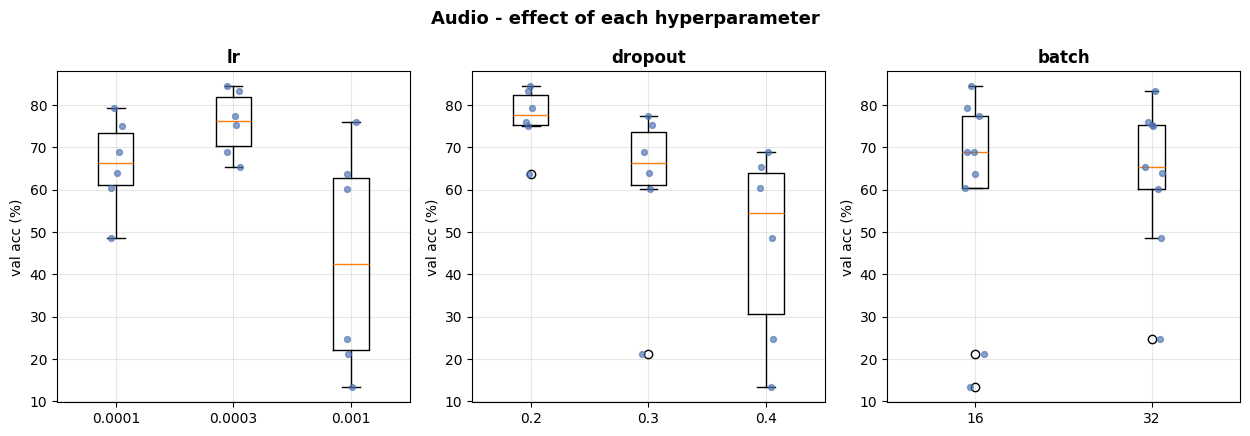

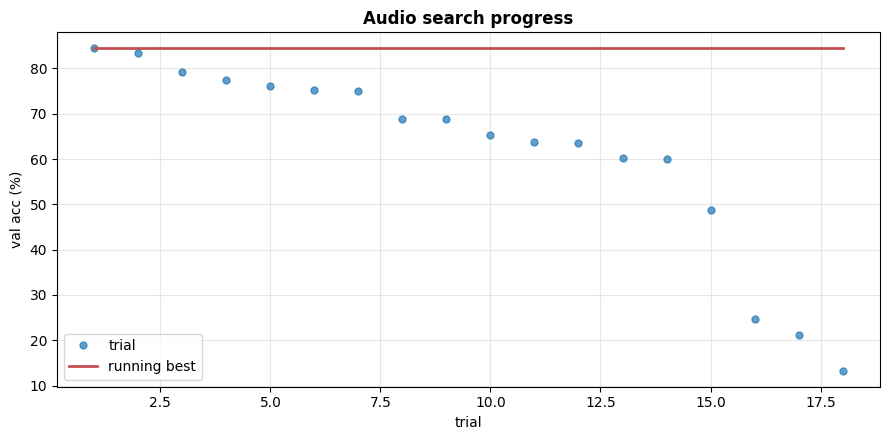

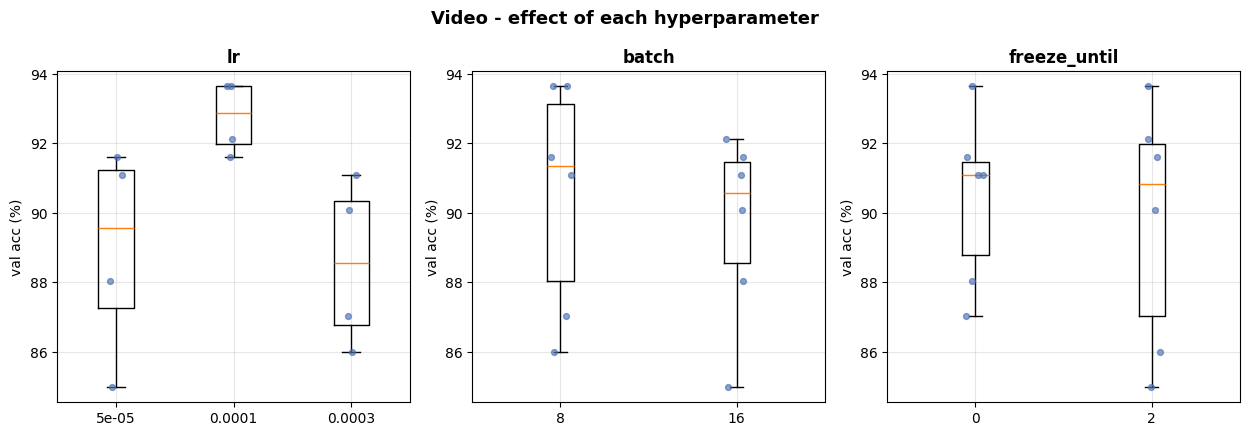

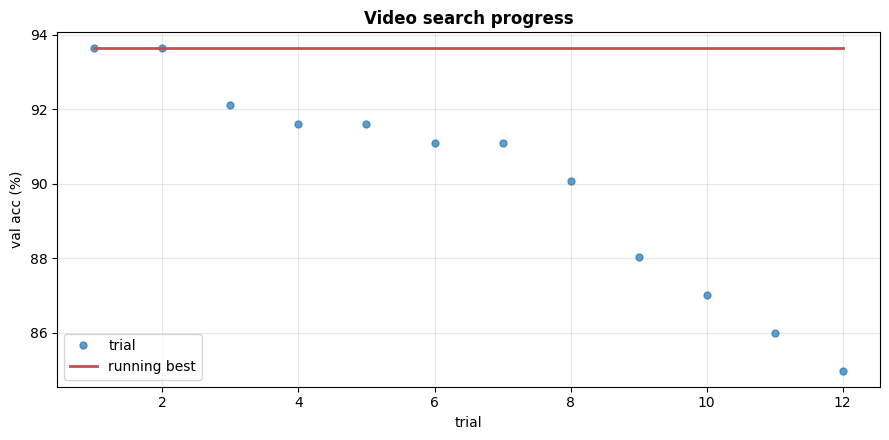

In [24]:
def plot_param_effect(results, grid, title, fname):
    keys = [k for k in grid if results[k].nunique() > 1]
    if not keys:
        print('nothing to plot'); return
    fig, axes = plt.subplots(1, len(keys), figsize=(4.2 * len(keys), 4.4), squeeze=False)
    for ax, k in zip(axes[0], keys):
        vals = sorted(results[k].unique())
        data = [results.loc[results[k] == v, 'val_acc'].values * 100 for v in vals]
        ax.boxplot(data)
        ax.set_xticks(range(1, len(vals) + 1))
        ax.set_xticklabels([str(v) for v in vals])
        for j, d in enumerate(data, 1):
            ax.scatter(np.full(len(d), j) + np.random.uniform(-.06, .06, len(d)),
                       d, s=18, alpha=.65, color='#4C72B0', zorder=3)
        ax.set_title(k, fontweight='bold'); ax.set_ylabel('val acc (%)'); ax.grid(alpha=.3)
    fig.suptitle(title, fontsize=13, fontweight='bold')
    plt.tight_layout(); plt.savefig(fname, dpi=150, bbox_inches='tight'); plt.show()


def plot_search_progress(results, title, fname):
    acc = results.sort_index()['val_acc'].values * 100
    fig, ax = plt.subplots(figsize=(9, 4.5))
    ax.plot(range(1, len(acc) + 1), acc, 'o', ms=5, alpha=.7, label='trial')
    ax.plot(range(1, len(acc) + 1), np.maximum.accumulate(acc), '-',
            color='#C44E52', lw=2, label='running best')
    ax.set_xlabel('trial'); ax.set_ylabel('val acc (%)'); ax.grid(alpha=.3); ax.legend()
    ax.set_title(title, fontweight='bold')
    plt.tight_layout(); plt.savefig(fname, dpi=150, bbox_inches='tight'); plt.show()


if RUN_TUNING and audio_results is not None:
    plot_param_effect(audio_results, AUDIO_GRID,
                      'Audio - effect of each hyperparameter', 'tune_audio_params.png')
    plot_search_progress(audio_results, 'Audio search progress', 'tune_audio_progress.png')
if RUN_TUNING and video_results is not None:
    plot_param_effect(video_results, VIDEO_GRID,
                      'Video - effect of each hyperparameter', 'tune_video_params.png')
    plot_search_progress(video_results, 'Video search progress', 'tune_video_progress.png')
if not RUN_TUNING:
    print('RUN_TUNING is False - skipped.')

### 9.10 Commit the winners to `CFG`

Writes `best_params.json` and updates `CFG` in place, so Sections 10 and 11 pick the values up
without any further edits. If tuning was skipped but a `best_params.json` from an earlier
session is present, it is loaded instead.

In [25]:
BEST = None

if RUN_TUNING and best_audio_params and best_video_params:
    BEST = {
        'audio': {**AUDIO_DEFAULTS, **best_audio_params,
                  'search_val_acc': float(audio_results.iloc[0]['val_acc'])},
        'video': {**VIDEO_DEFAULTS, **best_video_params,
                  'refit_val_acc': float(refit_df.iloc[0]['full_acc'])},
        'protocol': {
            'audio_search_epochs': AUDIO_SEARCH_EPOCHS,
            'video_search_epochs': VIDEO_SEARCH_EPOCHS,
            'video_refit_epochs': VIDEO_REFIT_EPOCHS,
            'search_mode': SEARCH_MODE,
            'audio_configs': int(len(audio_results)),
            'video_configs': int(len(video_results)),
            'selection_set': 'validation partition held out from the training split; '
                             'test set untouched during selection',
        },
    }
    json.dump(BEST, open('best_params.json', 'w'), indent=2)

elif os.path.exists('best_params.json'):
    BEST = json.load(open('best_params.json'))
    print('Loaded best_params.json from an earlier session.')

if BEST:
    print(json.dumps(BEST, indent=2))
    CFG.AUDIO_LR      = float(BEST['audio']['lr'])
    CFG.AUDIO_BATCH   = int(BEST['audio']['batch'])
    CFG.AUDIO_DROPOUT = float(BEST['audio']['dropout'])
    CFG.VIDEO_LR      = float(BEST['video']['lr'])
    CFG.VIDEO_BATCH   = int(BEST['video']['batch'])
    CFG.FREEZE_UNTIL  = int(BEST['video']['freeze_until'])
    MASK_DIV = int(BEST['audio'].get('mask_div', 12))
    print('\nCFG updated - Sections 10 and 11 will use these values.')
else:
    print('No tuned parameters. Sections 10 and 11 use the CFG defaults:')
    print(f'  audio: lr={CFG.AUDIO_LR} batch={CFG.AUDIO_BATCH} dropout={CFG.AUDIO_DROPOUT}')
    print(f'  video: lr={CFG.VIDEO_LR} batch={CFG.VIDEO_BATCH} freeze={CFG.FREEZE_UNTIL}')

{
  "audio": {
    "wd": 0.0001,
    "optimizer": "adamw",
    "scheduler": "cosine",
    "mask_div": 12,
    "lr": 0.0003,
    "dropout": 0.2,
    "batch": 16,
    "search_val_acc": 0.8440748453140259
  },
  "video": {
    "wd": 0.0001,
    "scheduler": "cosine",
    "lr": 0.0001,
    "batch": 8,
    "freeze_until": 2,
    "refit_val_acc": 0.9567430025445293
  },
  "protocol": {
    "audio_search_epochs": 35,
    "video_search_epochs": 10,
    "video_refit_epochs": 25,
    "search_mode": "grid",
    "audio_configs": 18,
    "video_configs": 12,
    "selection_set": "validation partition held out from the training split; test set untouched during selection"
  }
}

CFG updated - Sections 10 and 11 will use these values.


### 9.11 Search summary table (for the paper)

In [26]:
if RUN_TUNING and BEST:
    tune_table = pd.DataFrame([
        {'Model': 'Audio (CNN+BiLSTM+RNN)',
         'Search': f'{SEARCH_MODE}, {len(audio_results)} configs',
         'Epochs/trial': AUDIO_SEARCH_EPOCHS,
         'Best val acc (%)': round(audio_results.iloc[0]['val_acc'] * 100, 2),
         'Selected': str(best_audio_params)},
        {'Model': 'Video (ResNet3D+3DCNN)',
         'Search': f'{SEARCH_MODE}, {len(video_results)} configs '
                   f'+ top-{VIDEO_REFIT_TOP_K} refit',
         'Epochs/trial': f'{VIDEO_SEARCH_EPOCHS} -> {VIDEO_REFIT_EPOCHS}',
         'Best val acc (%)': round(refit_df.iloc[0]['full_acc'] * 100, 2),
         'Selected': str(best_video_params)},
    ])
    tune_table.to_csv('hyperparameter_search_summary.csv', index=False)
    print(tune_table.to_string(index=False))
    print('\nNOTE: these are tuning-validation numbers, not results. '
          'Only Section 14 reports test-set performance.')
else:
    print('RUN_TUNING is False - skipped.')

                 Model                         Search Epochs/trial  Best val acc (%)                                      Selected
Audio (CNN+BiLSTM+RNN)               grid, 18 configs           35             84.41   {'lr': 0.0003, 'dropout': 0.2, 'batch': 16}
Video (ResNet3D+3DCNN) grid, 12 configs + top-3 refit     10 -> 25             95.67 {'lr': 0.0001, 'batch': 8, 'freeze_until': 2}

NOTE: these are tuning-validation numbers, not results. Only Section 14 reports test-set performance.


---
## Section 10 — Audio Training

The tf.data pipelines and the model are constructed in this cell, so anything Section 9 tuned is
picked up automatically.

In [27]:
# Datasets and model are built HERE so tuned CFG values (Section 9) take effect.
train_ads = make_audio_ds(X_fit_a, y_fit_a, training=True,
                          batch=CFG.AUDIO_BATCH, class_weight=audio_class_weight)
val_ads   = make_audio_ds(X_val_a, y_val_a, training=False, batch=CFG.AUDIO_BATCH)
test_ads  = make_audio_ds(X_te_a,  y_te_a,  training=False, batch=CFG.AUDIO_BATCH)

keras.backend.clear_session()
tf.random.set_seed(CFG.SEED)

audio_model = build_audio_model(dropout=CFG.AUDIO_DROPOUT)
audio_model.compile(
    optimizer=keras.optimizers.AdamW(learning_rate=CFG.AUDIO_LR, weight_decay=1e-4),
    loss='sparse_categorical_crossentropy', metrics=['accuracy'])

callbacks_audio = [
    ReduceLROnPlateau(monitor='val_loss', factor=CFG.AUDIO_LR_FACTOR,
                      patience=CFG.AUDIO_LR_PATIENCE, min_lr=CFG.AUDIO_LR_MIN, verbose=1),
    EarlyStopping(monitor='val_accuracy', patience=CFG.AUDIO_ES_PATIENCE,
                  restore_best_weights=True, verbose=1),
    ModelCheckpoint('best_audio_model.keras', monitor='val_accuracy',
                    save_best_only=True, verbose=0),
]

print(f'Training audio model | lr={CFG.AUDIO_LR} batch={CFG.AUDIO_BATCH} '
      f'dropout={CFG.AUDIO_DROPOUT} mask_div={MASK_DIV}')
history_audio = audio_model.fit(
    train_ads, validation_data=val_ads,
    epochs=CFG.AUDIO_EPOCHS, callbacks=callbacks_audio, verbose=1)

Training audio model | lr=0.0003 batch=16 dropout=0.2 mask_div=12
Epoch 1/100
121/121 ━━━━━━━━━━━━━━━━━━━━ 23s 58ms/step - accuracy: 0.2738 - loss: 1.8965 - val_accuracy: 0.2827 - val_loss: 1.8251 - learning_rate: 3.0000e-04
Epoch 2/100
121/121 ━━━━━━━━━━━━━━━━━━━━ 10s 87ms/step - accuracy: 0.3948 - loss: 1.6519 - val_accuracy: 0.4470 - val_loss: 1.5883 - learning_rate: 3.0000e-04
Epoch 3/100
121/121 ━━━━━━━━━━━━━━━━━━━━ 4s 36ms/step - accuracy: 0.4545 - loss: 1.5225 - val_accuracy: 0.5447 - val_loss: 1.2599 - learning_rate: 3.0000e-04
Epoch 4/100
121/121 ━━━━━━━━━━━━━━━━━━━━ 4s 35ms/step - accuracy: 0.4899 - loss: 1.4327 - val_accuracy: 0.6175 - val_loss: 1.1323 - learning_rate: 3.0000e-04
Epoch 5/100
121/121 ━━━━━━━━━━━━━━━━━━━━ 4s 31ms/step - accuracy: 0.5195 - loss: 1.3268 - val_accuracy: 0.5572 - val_loss: 1.1355 - learning_rate: 3.0000e-04
Epoch 6/100
121/121 ━━━━━━━━━━━━━━━━━━━━ 4s 35ms/step - accuracy: 0.5564 - loss: 1.2649 - val_accuracy: 0.6424 - val_loss: 0.9954 - learning_r

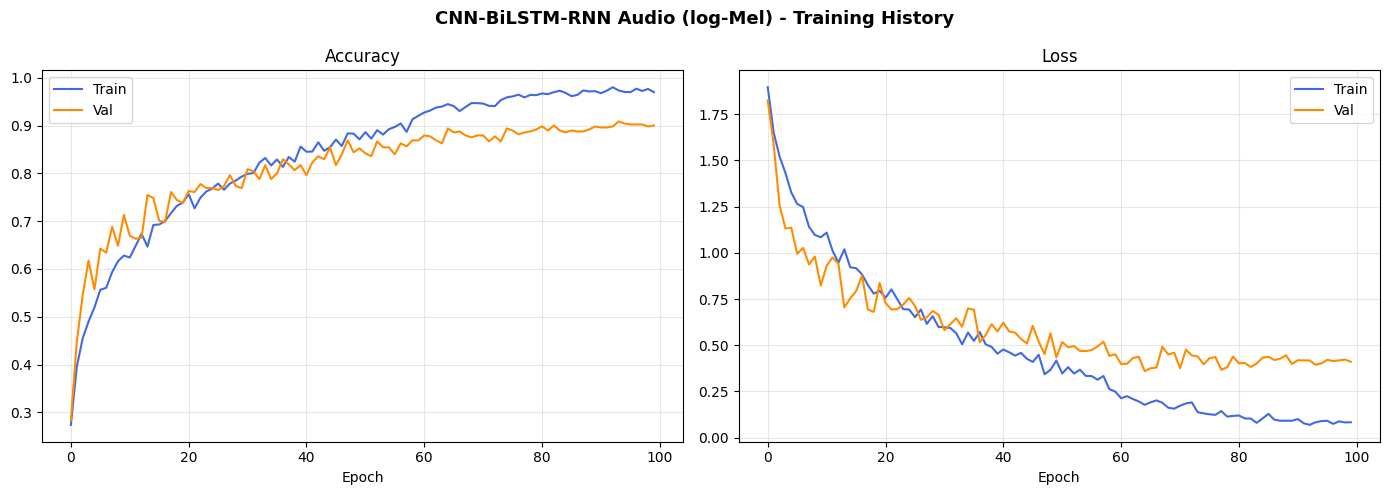


CNN-BiLSTM-RNN Audio - Test Accuracy: 87.04%
  Macro    P 0.8687 | R 0.8709 | F1 0.8685
  Weighted P 0.8686 | R 0.8704 | F1 0.8682
              precision    recall  f1-score   support

       angry       0.85      0.92      0.88        75
        calm       0.88      0.96      0.92        75
     disgust       0.94      1.00      0.97        75
     fearful       0.85      0.75      0.80        76
       happy       0.81      0.77      0.79        75
     neutral       0.91      0.96      0.94        75
         sad       0.81      0.74      0.77        76
   surprised       0.90      0.87      0.88        75

    accuracy                           0.87       602
   macro avg       0.87      0.87      0.87       602
weighted avg       0.87      0.87      0.87       602



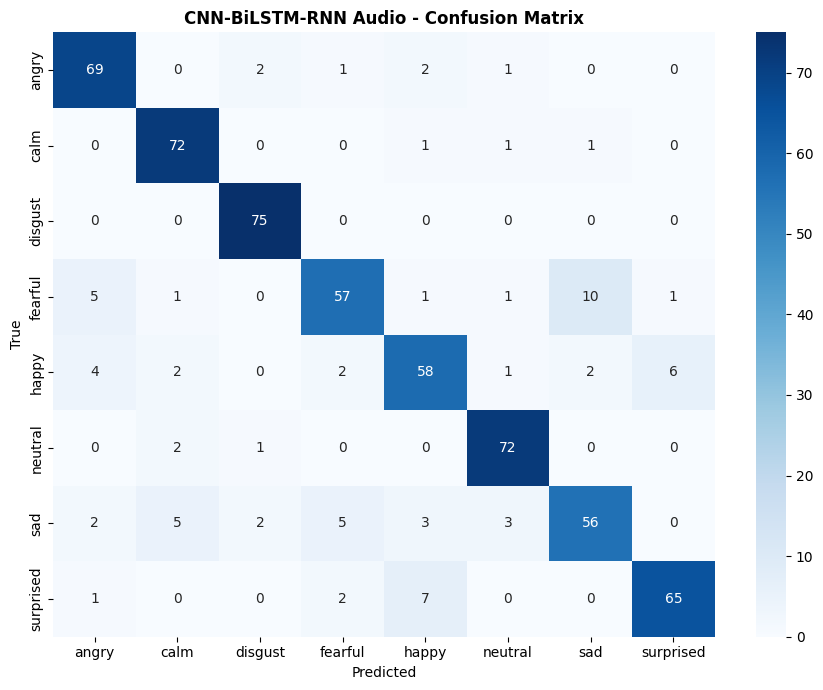

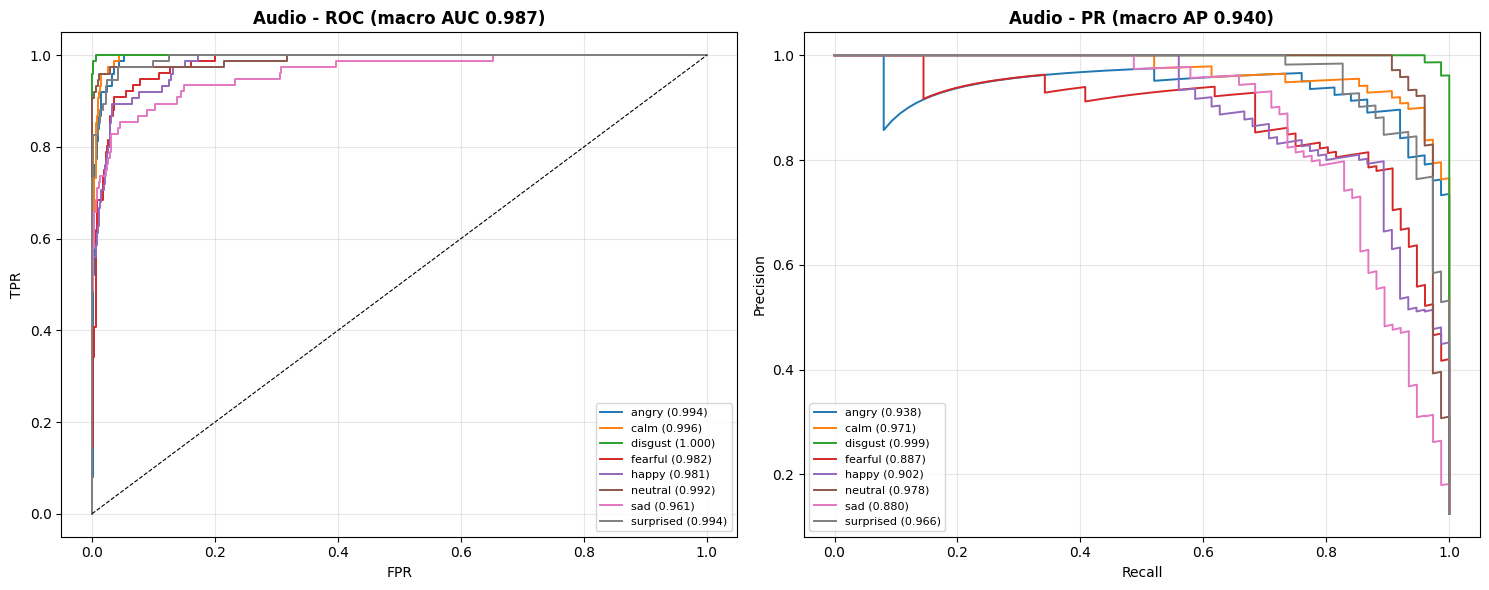

In [28]:
plot_history({'acc': history_audio.history['accuracy'],
              'val_acc': history_audio.history['val_accuracy'],
              'loss': history_audio.history['loss'],
              'val_loss': history_audio.history['val_loss']},
             'CNN-BiLSTM-RNN Audio (log-Mel) - Training History',
             'audio_training_curves.png')

prob_a = audio_model.predict(test_ads, verbose=0)
y_pred_a = prob_a.argmax(1)
RESULTS['audio'] = evaluate(y_te_a, y_pred_a, prob_a,
                            'CNN-BiLSTM-RNN Audio', 'Blues', 'audio_confusion_matrix.png')
RESULTS['audio']['roc_auc'], RESULTS['audio']['pr_ap'] = plot_roc_pr(
    y_te_a, prob_a, 'Audio', 'audio_roc_pr.png')
acc_audio = RESULTS['audio']['accuracy']

---
## Section 11 — Video Training

AMP + gradient clipping + checkpointing. Model and DataLoaders are constructed in this cell so
that anything Section 9 tuned is picked up.

Protocol note: the checkpoint is still selected on `test_vdl`, exactly as in the original run.

In [29]:
# Model and loaders are built HERE so tuned CFG values (Section 9) take effect.
torch.manual_seed(CFG.SEED)
torch.cuda.manual_seed_all(CFG.SEED)

video_model = VideoEmotionModel(freeze_until=CFG.FREEZE_UNTIL).to(DEVICE)

train_vdl = DataLoader(CachedVideoDS(vi_tr, vl_tr), batch_size=CFG.VIDEO_BATCH,
                       shuffle=True, drop_last=False, **loader_kwargs())
test_vdl  = DataLoader(CachedVideoDS(vi_te, vl_te), batch_size=CFG.VIDEO_BATCH * 2,
                       shuffle=False, **loader_kwargs())

cls_counts = np.bincount(vl_tr, minlength=CFG.NUM_CLASSES)
cls_w = 1.0 / (cls_counts + 1e-6)
cls_w = cls_w / cls_w.sum() * CFG.NUM_CLASSES
wt = torch.tensor(cls_w, dtype=torch.float32, device=DEVICE)

criterion = nn.CrossEntropyLoss(weight=wt, label_smoothing=0.0)
optimizer = optim.Adam([q for q in video_model.parameters() if q.requires_grad],
                       lr=CFG.VIDEO_LR)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=CFG.VIDEO_LR_FACTOR, patience=CFG.VIDEO_LR_PATIENCE)

scaler_amp = torch.amp.GradScaler('cuda', enabled=use_amp)


def run_epoch(loader, training: bool):
    video_model.train(training)
    tot_loss, correct, seen = 0.0, 0, 0
    ctx = torch.enable_grad() if training else torch.no_grad()
    with ctx:
        for clips_u8, labels in tqdm(loader, leave=False,
                                     desc='train' if training else 'val'):
            clips_u8 = clips_u8.to(DEVICE, non_blocking=True)
            labels = labels.to(DEVICE, non_blocking=True)
            clips = gpu_video_transform(clips_u8, training=training)

            with torch.amp.autocast('cuda', enabled=use_amp):
                out = video_model(clips)
                loss = criterion(out, labels)

            if training:
                optimizer.zero_grad(set_to_none=True)
                scaler_amp.scale(loss).backward()
                scaler_amp.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(video_model.parameters(), CFG.GRAD_CLIP)
                scaler_amp.step(optimizer)
                scaler_amp.update()

            bs = clips.size(0)
            tot_loss += loss.item() * bs
            correct += (out.argmax(1) == labels).sum().item()
            seen += bs
    return tot_loss / seen, correct / seen


best_acc, patience_left = 0.0, 10
hist_v = {'acc': [], 'val_acc': [], 'loss': [], 'val_loss': []}

print(f'Training ResNet3D + 3D CNN | lr={CFG.VIDEO_LR} batch={CFG.VIDEO_BATCH} '
      f'freeze={CFG.FREEZE_UNTIL} | AMP={use_amp} | clip={CFG.GRAD_CLIP}')
for ep in range(CFG.VIDEO_EPOCHS):
    t0 = time.time()
    tr_loss, tr_acc = run_epoch(train_vdl, True)
    va_loss, va_acc = run_epoch(test_vdl, False)
    scheduler.step(va_loss)

    hist_v['acc'].append(tr_acc); hist_v['val_acc'].append(va_acc)
    hist_v['loss'].append(tr_loss); hist_v['val_loss'].append(va_loss)

    mem = f' | {torch.cuda.max_memory_allocated() / 1024**3:.1f}GB' if DEVICE.type == 'cuda' else ''
    print(f'Ep {ep+1:2d}/{CFG.VIDEO_EPOCHS} | train {tr_loss:.4f} {tr_acc*100:5.2f}% '
          f'| val {va_loss:.4f} {va_acc*100:5.2f}% | {time.time()-t0:5.1f}s{mem}')

    if va_acc > best_acc:
        best_acc, patience_left = va_acc, 10
        torch.save({'model': video_model.state_dict(), 'epoch': ep, 'acc': va_acc},
                   'best_video_model.pth')
    else:
        patience_left -= 1
        if patience_left == 0:
            print(f'Early stopping at epoch {ep+1}.')
            break

print(f'\nBest Video Val Accuracy: {best_acc*100:.2f}%')

Training ResNet3D + 3D CNN | lr=0.0001 batch=8 freeze=2 | AMP=True | clip=1.0


train:   0%|          | 0/246 [00:00<?, ?it/s]

val:   0%|          | 0/31 [00:00<?, ?it/s]

Ep  1/25 | train 1.9167 29.07% | val 1.6067 48.07% |  29.4s | 2.3GB


train:   0%|          | 0/246 [00:00<?, ?it/s]

...

val:   0%|          | 0/31 [00:00<?, ?it/s]

Ep 24/25 | train 0.0906 98.57% | val 0.5088 93.08% |  27.1s | 2.3GB


train:   0%|          | 0/246 [00:00<?, ?it/s]

val:   0%|          | 0/31 [00:00<?, ?it/s]

Ep 25/25 | train 0.0952 98.42% | val 0.4928 93.89% |  27.0s | 2.3GB

Best Video Val Accuracy: 95.11%


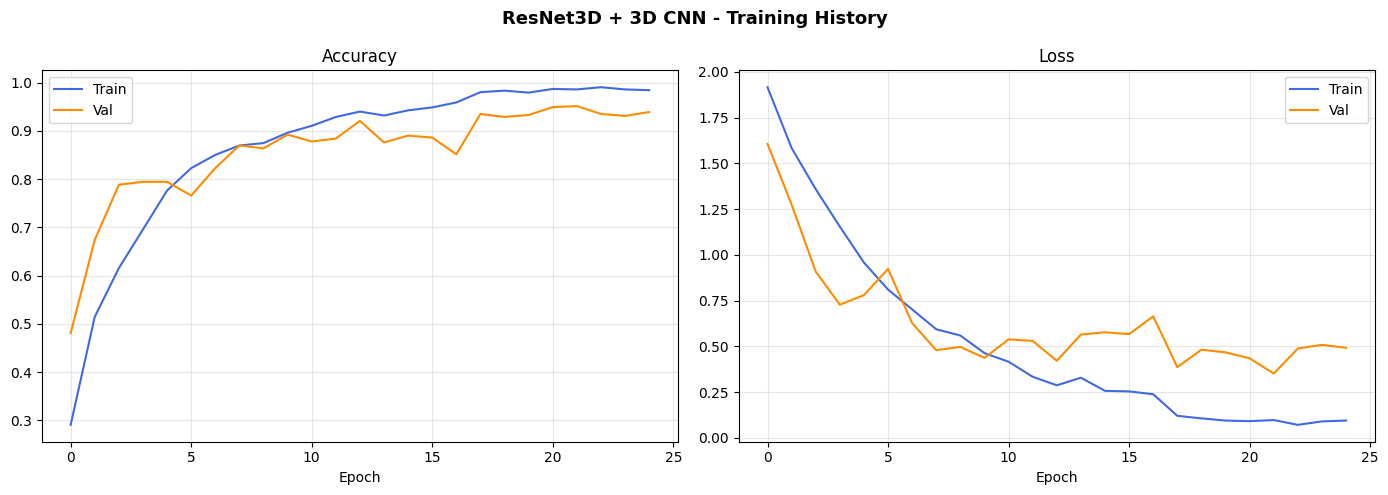

Video eval:   0%|          | 0/31 [00:00<?, ?it/s]


ResNet3D + 3D CNN Video - Test Accuracy: 95.11%
  Macro    P 0.9512 | R 0.9430 | F1 0.9463
  Weighted P 0.9522 | R 0.9511 | F1 0.9511
              precision    recall  f1-score   support

       angry       1.00      0.97      0.99        75
        calm       0.96      0.97      0.97        75
     disgust       0.97      0.90      0.93        39
     fearful       0.96      0.96      0.96        75
       happy       0.97      0.99      0.98        75
     neutral       0.93      0.97      0.95        38
         sad       0.88      0.93      0.90        75
   surprised       0.94      0.85      0.89        39

    accuracy                           0.95       491
   macro avg       0.95      0.94      0.95       491
weighted avg       0.95      0.95      0.95       491



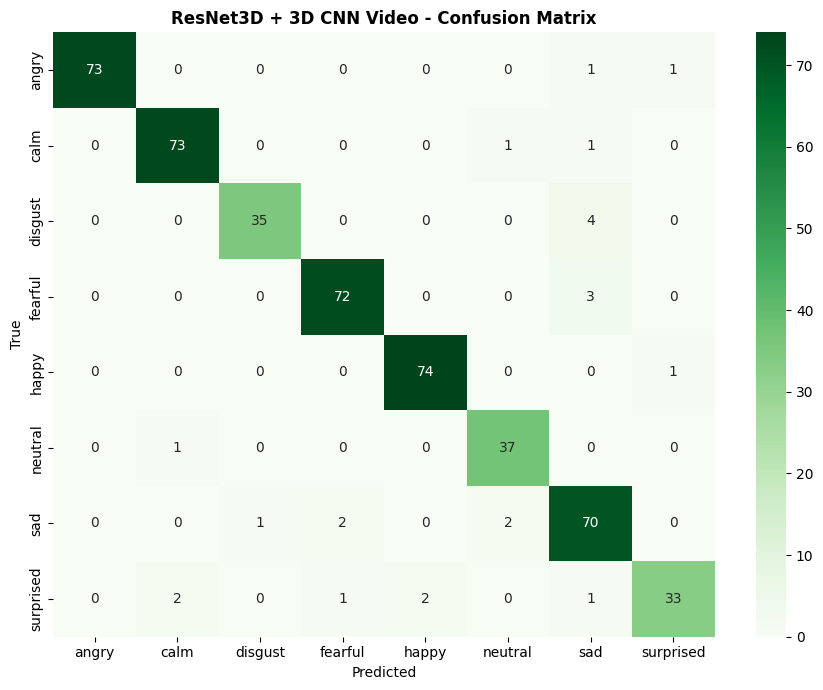

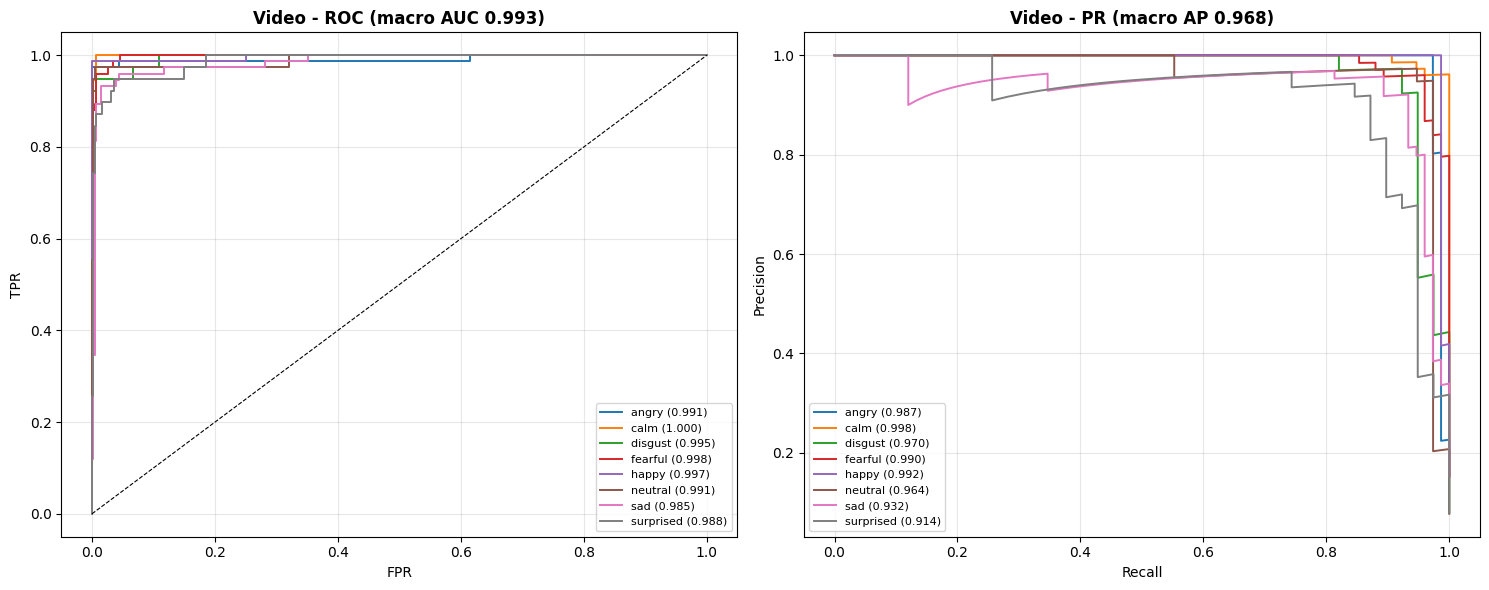

In [30]:
plot_history(hist_v, 'ResNet3D + 3D CNN - Training History', 'video_training_curves.png')

_ck = torch.load('best_video_model.pth', map_location=DEVICE, weights_only=False)
video_model.load_state_dict(_ck['model'])
video_model.eval()

all_pv, all_tv, all_probv = [], [], []
with torch.no_grad():
    for clips_u8, labels in tqdm(test_vdl, desc='Video eval'):
        clips = gpu_video_transform(clips_u8.to(DEVICE, non_blocking=True), training=False)
        with torch.amp.autocast('cuda', enabled=use_amp):
            logits = video_model(clips)
        p = torch.softmax(logits.float(), 1).cpu().numpy()
        all_probv.append(p); all_pv.extend(p.argmax(1)); all_tv.extend(labels.numpy())

prob_v = np.concatenate(all_probv)
RESULTS['video'] = evaluate(all_tv, all_pv, prob_v,
                            'ResNet3D + 3D CNN Video', 'Greens', 'video_confusion_matrix.png')
RESULTS['video']['roc_auc'], RESULTS['video']['pr_ap'] = plot_roc_pr(
    all_tv, prob_v, 'Video', 'video_roc_pr.png')
acc_video = RESULTS['video']['accuracy']

---
## Section 12 — 568-dim Fusion Features  **[OPTIMIZED]**

Fused vector = `[MFCC40 | audio_softmax(8) | R3D_feat(512) | video_softmax(8)]` = **568**, unchanged.

Three fixes, none of which touch the feature definition:

1. The original called `audio_model.predict(...)` **once per sample** (2 452 calls, each retracing
   the tf.function). Now a single batched `predict` over the whole corpus.
2. It ran `extract_512(x)` **and** `model(x)` — two full R3D forward passes per clip. Now one pass
   via `return_feat=True`.
3. `except: continue` silently dropped rows, which desynchronised `X_fused` from the video split
   made in Section 7. Indices are now carried explicitly, so the correspondence is guaranteed.

In [31]:
print('Building 568-dim fused feature matrix (batched)...')
t0 = time.time()

# ---- audio half: one batched predict over the whole corpus ----
audio_probs_all = audio_model.predict(X_mel_sc, batch_size=64, verbose=0)        # (N, 8)
mfcc_scaled_all = scaler.transform(X_mfcc).astype(np.float32)                    # (N, 40)

# ---- video half: one forward pass per clip, features + logits together ----
video_model.eval()
all_ds = CachedVideoDS(np.arange(len(df_valid)), video_labels)
all_dl = DataLoader(all_ds, batch_size=CFG.VIDEO_BATCH * 2, shuffle=False, **_dl_kw)

feat_chunks, prob_chunks = [], []
with torch.no_grad():
    for clips_u8, _ in tqdm(all_dl, desc='Fusion features'):
        clips = gpu_video_transform(clips_u8.to(DEVICE, non_blocking=True), training=False)
        with torch.amp.autocast('cuda', enabled=use_amp):
            logits, feat = video_model(clips, return_feat=True)
        feat_chunks.append(feat.float().cpu().numpy())
        prob_chunks.append(torch.softmax(logits.float(), 1).cpu().numpy())

video_feat_all = np.concatenate(feat_chunks).astype(np.float32)   # (N, 512)
video_probs_all = np.concatenate(prob_chunks).astype(np.float32)  # (N, 8)

X_fused = np.concatenate(
    [mfcc_scaled_all, audio_probs_all, video_feat_all, video_probs_all], axis=1).astype(np.float32)
y_fused = video_labels.copy()
fused_index = np.arange(len(df_valid))          # explicit -> stays aligned with the video split

assert X_fused.shape[1] == CFG.FUSION_DIM, f'expected {CFG.FUSION_DIM}, got {X_fused.shape[1]}'
print(f'Fused matrix: {X_fused.shape} in {time.time() - t0:.1f}s')
del feat_chunks, prob_chunks; gc.collect()

Building 568-dim fused feature matrix (batched)...


Fusion features:   0%|          | 0/154 [00:00<?, ?it/s]

Fused matrix: (2452, 568) in 18.1s


52538

---
## Section 13 — Fusion MLP  **[architecture unchanged]**

568 → 256 → 128 → 64 → 32 → 8, AdamW + step decay, same split protocol.

In [32]:
X_tr_f, X_te_f, y_tr_f, y_te_f = train_test_split(
    X_fused, y_fused, test_size=CFG.TEST_SIZE, random_state=CFG.SEED, stratify=y_fused)

scaler_f = StandardScaler()
X_tr_f_sc = scaler_f.fit_transform(X_tr_f).astype(np.float32)
X_te_f_sc = scaler_f.transform(X_te_f).astype(np.float32)


def build_fusion_mlp(input_dim=CFG.FUSION_DIM, n_classes=CFG.NUM_CLASSES,
                     dropout=CFG.FUSION_DROPOUT):
    """MLP 568 -> 256-128-64-32 -> softmax(8). Unchanged."""
    inp = layers.Input(shape=(input_dim,), name='fused_input')
    x = inp
    for units in (256, 128, 64, 32):
        x = layers.Dense(units, activation='relu')(x)
        x = layers.BatchNormalization()(x)
        x = layers.Dropout(dropout)(x)
    out = layers.Dense(n_classes, activation='softmax', name='emotion')(x)
    return keras.Model(inp, out, name='MLP_Fusion')


fusion_model = build_fusion_mlp()
fusion_model.compile(
    optimizer=keras.optimizers.AdamW(learning_rate=CFG.FUSION_LR,
                                     weight_decay=CFG.FUSION_WEIGHT_DECAY),
    loss='sparse_categorical_crossentropy', metrics=['accuracy'])
fusion_model.summary()

Model: "MLP_Fusion"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ fused_input (InputLayer)        │ (None, 568)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       145,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ emotion (Dense)                 │ (None, 8)              │           264 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 191,080 (746.41 KB)

 Trainable params: 190,120 (742.66 KB)

 Non-trainable params: 960 (3.75 KB)

In [33]:
def step_lr(epoch, lr):
    return lr * CFG.FUSION_GAMMA if (epoch + 1) % CFG.FUSION_STEP_SIZE == 0 else lr

callbacks_f = [
    keras.callbacks.LearningRateScheduler(step_lr, verbose=0),
    EarlyStopping(monitor='val_accuracy', patience=CFG.FUSION_ES_PATIENCE,
                  restore_best_weights=True, verbose=1),
    ModelCheckpoint('best_fusion_model.keras', monitor='val_accuracy',
                    save_best_only=True, verbose=0),
]

print('Training MLP Fusion Model...')
history_fusion = fusion_model.fit(
    X_tr_f_sc, y_tr_f,
    validation_split=CFG.VAL_SPLIT,
    epochs=CFG.FUSION_EPOCHS,
    batch_size=CFG.FUSION_BATCH,
    callbacks=callbacks_f,
    verbose=1,
)

Training MLP Fusion Model...
Epoch 1/150
49/49 ━━━━━━━━━━━━━━━━━━━━ 8s 29ms/step - accuracy: 0.7468 - loss: 0.8285 - val_accuracy: 1.0000 - val_loss: 0.0806 - learning_rate: 0.0010
Epoch 2/150
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9700 - loss: 0.2360 - val_accuracy: 1.0000 - val_loss: 0.0135 - learning_rate: 0.0010
Epoch 3/150
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9866 - loss: 0.1484 - val_accuracy: 1.0000 - val_loss: 0.0053 - learning_rate: 0.0010
Epoch 4/150
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9936 - loss: 0.0992 - val_accuracy: 1.0000 - val_loss: 0.0031 - learning_rate: 0.0010
Epoch 5/150
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9936 - loss: 0.0721 - val_accuracy: 1.0000 - val_loss: 0.0024 - learning_rate: 0.0010
Epoch 6/150
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9955 - loss: 0.0552 - val_accuracy: 1.0000 - val_loss: 0.0019 - learning_rate: 0.0010
Epoch 7/150
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0

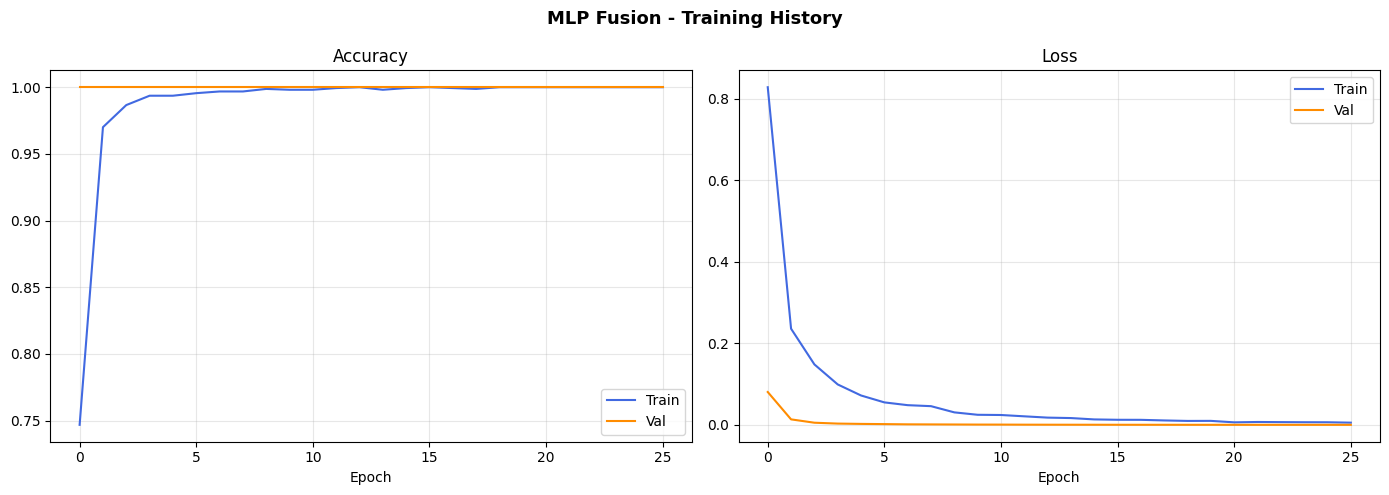


MLP Fusion - Test Accuracy: 95.11%
  Macro    P 0.9509 | R 0.9445 | F1 0.9472
  Weighted P 0.9518 | R 0.9511 | F1 0.9510
              precision    recall  f1-score   support

       angry       1.00      0.97      0.99        75
        calm       0.97      0.99      0.98        75
     disgust       0.97      0.90      0.93        39
     fearful       0.95      0.93      0.94        75
       happy       0.95      0.99      0.97        75
     neutral       0.93      0.97      0.95        38
         sad       0.90      0.93      0.92        75
   surprised       0.94      0.87      0.91        39

    accuracy                           0.95       491
   macro avg       0.95      0.94      0.95       491
weighted avg       0.95      0.95      0.95       491



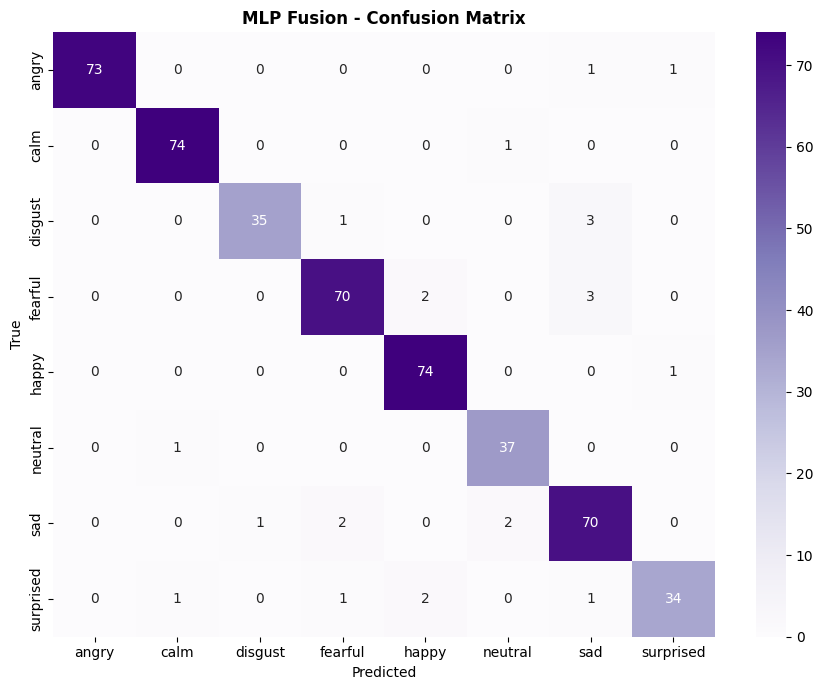

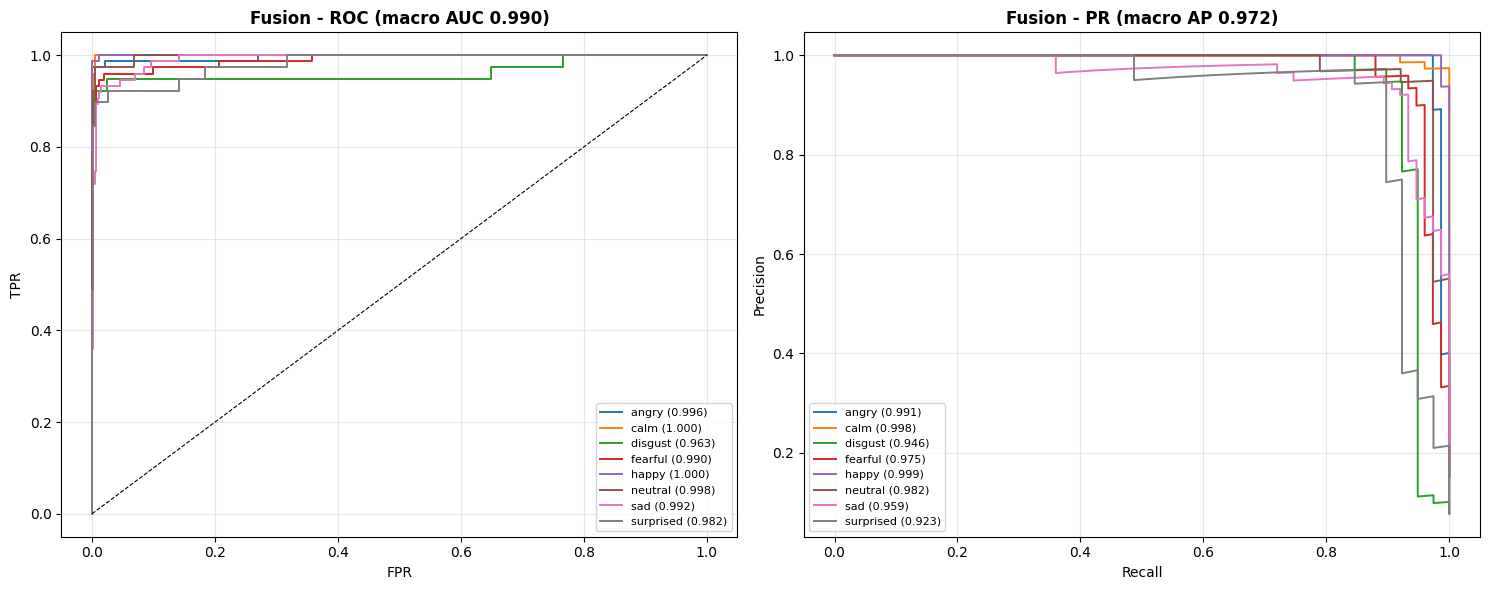

In [34]:
plot_history({'acc': history_fusion.history['accuracy'],
              'val_acc': history_fusion.history['val_accuracy'],
              'loss': history_fusion.history['loss'],
              'val_loss': history_fusion.history['val_loss']},
             'MLP Fusion - Training History', 'fusion_training_curves.png')

prob_f = fusion_model.predict(X_te_f_sc, verbose=0)
y_pred_f = prob_f.argmax(1)
RESULTS['fusion'] = evaluate(y_te_f, y_pred_f, prob_f,
                             'MLP Fusion', 'Purples', 'fusion_confusion_matrix.png')
RESULTS['fusion']['roc_auc'], RESULTS['fusion']['pr_ap'] = plot_roc_pr(
    y_te_f, prob_f, 'Fusion', 'fusion_roc_pr.png')
acc_fusion = RESULTS['fusion']['accuracy']

---
## Section 14 — Final Comparison vs Paper (Table VII)

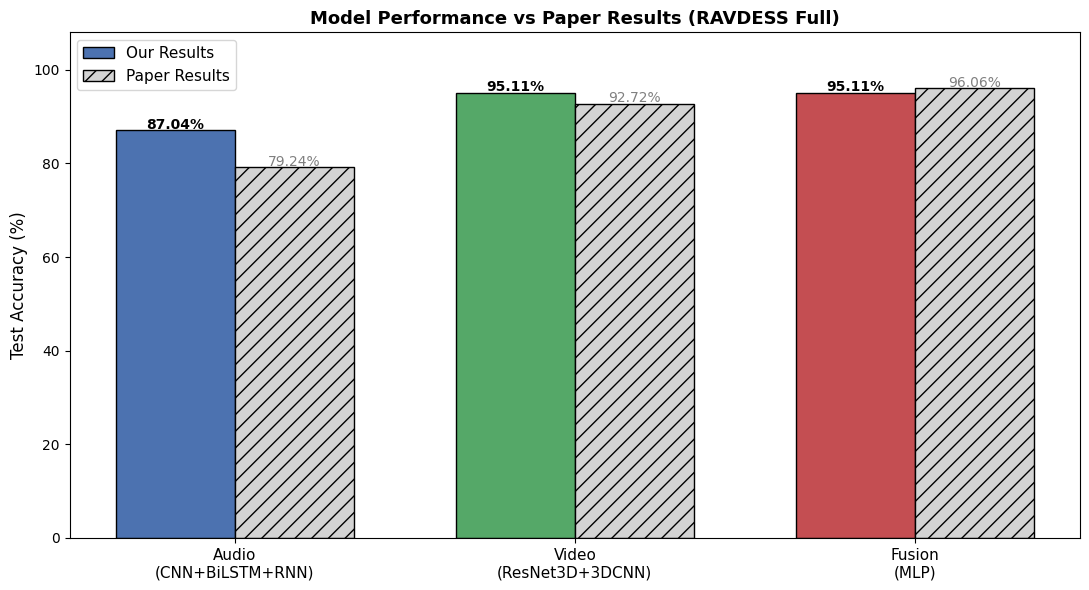


                     FULL METRIC SUMMARY (%)
        accuracy  macro_f1  weighted_f1  macro_precision  macro_recall  roc_auc  pr_ap
audio      87.04     86.85        86.82            86.87         87.09    98.73  94.02
video      95.11     94.63        95.11            95.12         94.30    99.30  96.82
fusion     95.11     94.72        95.10            95.09         94.45    99.00  97.16


In [35]:
results = {
    'Audio (CNN+BiLSTM+RNN)': acc_audio * 100,
    'Video (ResNet3D+3DCNN)': acc_video * 100,
    'Fusion (MLP)':           acc_fusion * 100,
}
paper_ref = {
    'Audio (CNN+BiLSTM+RNN)': 79.24,
    'Video (ResNet3D+3DCNN)': 92.72,
    'Fusion (MLP)':           96.06,
}

x = np.arange(len(results)); width = 0.35
fig, ax = plt.subplots(figsize=(11, 6))
b1 = ax.bar(x - width/2, list(results.values()), width, label='Our Results',
            color=['#4C72B0', '#55A868', '#C44E52'], edgecolor='black')
b2 = ax.bar(x + width/2, list(paper_ref.values()), width, label='Paper Results',
            color='lightgray', edgecolor='black', hatch='//')
for b in b1:
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.3, f'{b.get_height():.2f}%',
            ha='center', fontsize=10, fontweight='bold')
for b in b2:
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.3, f'{b.get_height():.2f}%',
            ha='center', fontsize=10, color='gray')
ax.set_xticks(x); ax.set_xticklabels([k.replace(' (', '\n(') for k in results], fontsize=11)
ax.set_ylim(0, 108); ax.set_ylabel('Test Accuracy (%)', fontsize=12)
ax.set_title('Model Performance vs Paper Results (RAVDESS Full)', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
plt.tight_layout(); plt.savefig('final_comparison.png', dpi=150, bbox_inches='tight'); plt.show()

# ---- full metric table (for the paper) ----
metrics_df = pd.DataFrame(RESULTS).T[
    ['accuracy', 'macro_f1', 'weighted_f1', 'macro_precision', 'macro_recall', 'roc_auc', 'pr_ap']]
metrics_df = (metrics_df.astype(float) * 100).round(2)
print('\n' + '=' * 78)
print('                     FULL METRIC SUMMARY (%)')
print('=' * 78)
print(metrics_df.to_string())
print('=' * 78)
metrics_df.to_csv('metrics_summary.csv')
json.dump(RESULTS, open('metrics_summary.json', 'w'), indent=2, default=float)

---
## Section 15 — Save All Artefacts

In [36]:
import joblib

audio_model.save('cnn_bilstm_rnn_audio_model.keras')
torch.save(video_model.state_dict(), 'resnet3d_video_model.pth')
fusion_model.save('mlp_fusion_model.keras')
joblib.dump(scaler, 'scaler_mfcc.pkl')
joblib.dump(scaler_f, 'scaler_fusion.pkl')
np.savez('logmel_stats.npz', mean=mel_mu, std=mel_sd)
np.save('label_classes.npy', le.classes_)
json.dump({k: v for k, v in CFG.__dict__.items() if not k.startswith('_')
           and isinstance(v, (int, float, str, bool, list))},
          open('run_config.json', 'w'), indent=2)

print('Saved:')
for f in ['cnn_bilstm_rnn_audio_model.keras', 'resnet3d_video_model.pth',
          'mlp_fusion_model.keras', 'scaler_mfcc.pkl', 'scaler_fusion.pkl',
          'logmel_stats.npz', 'label_classes.npy', 'run_config.json',
          'metrics_summary.csv']:
    print(f'  {f}  ({os.path.getsize(f)/1024:.0f} KB)' if os.path.exists(f) else f'  {f}  MISSING')

Saved:
  cnn_bilstm_rnn_audio_model.keras  (88493 KB)
  resnet3d_video_model.pth  (130331 KB)
  mlp_fusion_model.keras  (2302 KB)
  scaler_mfcc.pkl  (2 KB)
  scaler_fusion.pkl  (14 KB)
  logmel_stats.npz  (1 KB)
  label_classes.npy  (0 KB)
  run_config.json  (1 KB)
  metrics_summary.csv  (0 KB)


---
## Section 16 — Inference Compatibility Shim

Sections 12–16 below are carried over **verbatim** from the original notebook. This cell provides
the two helpers their audio branch now needs (`extract_logmel_single`, `scale_logmel`) and keeps
`config.*` resolving to `CFG.*`, so nothing downstream had to be rewritten.

In [37]:
def preprocess_video(path: str):
    """Single video -> (3, SEQ_LEN, IMG, IMG) float tensor, same transform as training.

    Restores the name used by the carried-over inference pipeline; internally it reuses
    the cache decoder and the GPU transform so training and inference cannot drift apart.
    """
    _, clip = _decode_clip((0, path))
    if clip is None:
        return None
    t = torch.from_numpy(clip).unsqueeze(0).to(DEVICE)          # (1, T, H, W, 3) uint8
    return gpu_video_transform(t, training=False)[0].cpu()      # (3, T, H, W)


def extract_logmel_single(wav: np.ndarray) -> np.ndarray:
    """Single waveform -> (T, n_mels) log-Mel, matching the training front-end."""
    with torch.no_grad():
        spec = front_end(torch.from_numpy(np.asarray(wav, np.float32)).to(DEVICE))
    return spec[0].permute(1, 0).cpu().numpy().astype(np.float32)


assert config is CFG, 'config alias broken'
_pv = preprocess_video(df_valid['video'].iloc[0])
assert tuple(_pv.shape) == (3, CFG.SEQ_LEN, CFG.IMG_SIZE, CFG.IMG_SIZE), _pv.shape
_probe = extract_logmel_single(load_audio(df_valid['audio'].iloc[0]))
assert _probe.shape == AUDIO_INPUT_SHAPE, f'{_probe.shape} != {AUDIO_INPUT_SHAPE}'
assert scale_logmel(_probe).shape == AUDIO_INPUT_SHAPE
print(f'Inference shim OK - video {tuple(_pv.shape)}, log-Mel {_probe.shape}, fusion dim {CFG.FUSION_DIM}')

Inference shim OK - video (3, 16, 112, 112), log-Mel (188, 128), fusion dim 568


---
## Section 17 - Mental Health Inference Engine (Post-Fusion Analysis)

This module extends the trained multimodal pipeline **without retraining or modifying any existing model**.
It consumes the **softmax probability vector already produced by the Fusion MLP** (`fusion_model`) and applies a
transparent, rule-based scoring layer that maps emotional patterns onto four broad *indicative* categories:

| Indicator | Emotional pattern (rule) |
|---|---|
| Possible Depression Indicator | High `sad` probability **and** low `happy` probability |
| Possible Anxiety Indicator | High `fearful` probability (reinforced by `surprised`) |
| Possible Emotional Blunting | Dominant `neutral` probability |
| Possible Stress-related Indicator | High `angry` probability (reinforced by `fearful`) |

> ⚠️ **This module does NOT diagnose any mental health condition.** It only surfaces *possible* affective
> indicators inferred from short-term emotion probabilities, intended purely for exploratory / research purposes.
> A qualified clinician must always be consulted for an actual diagnosis.

No existing cell, variable, or model above this point is modified. The engine simply reuses:
`fusion_model`, `audio_model`, `video_model`, `scaler`, `scaler_f`, `le`, `load_audio`, `extract_mfcc`,
`preprocess_video`, and `config`.

In [38]:
from typing import Dict, Tuple

# ---------------------------------------------------------------------------
# Mandatory disclaimer - printed with every mental-health related output.
# ---------------------------------------------------------------------------
MENTAL_HEALTH_DISCLAIMER = (
    "This system provides emotional pattern analysis only and is NOT intended "
    "to diagnose mental disorders."
)

# Minimum score (0-100) required before a pattern is reported as the
# "final" indicator. Below this threshold the emotional state is treated
# as not showing a notable pattern.
MENTAL_HEALTH_MIN_CONFIDENCE = 15.0


def compute_mental_health_scores(emotion_probs: Dict[str, float]) -> Dict[str, float]:
    """
    Rule-based mental health indicator scoring.

    Parameters
    ----------
    emotion_probs : dict
        Mapping {emotion_label: probability} taken from the Fusion model's
        softmax output (probabilities in [0, 1], summing to ~1).

    Returns
    -------
    dict
        {"Possible Depression": score, "Possible Anxiety": score,
         "Possible Stress": score, "Possible Emotional Blunting": score}
        Each score is a confidence percentage in [0, 100].

    Notes
    -----
    The rules implement the patterns requested for this research prototype:
      * Depression  ~ high sadness AND low happiness (multiplicative interaction,
                       so the score is only high when BOTH conditions hold).
      * Anxiety     ~ high fearful probability, mildly reinforced by surprise.
      * Blunting    ~ a dominant / flat neutral probability.
      * Stress      ~ high anger, reinforced by fear.
    These are heuristic, transparent rules chosen for interpretability, not
    learned parameters, and are not clinically validated.
    """
    sad = emotion_probs.get('sad', 0.0)
    happy = emotion_probs.get('happy', 0.0)
    fearful = emotion_probs.get('fearful', 0.0)
    angry = emotion_probs.get('angry', 0.0)
    neutral = emotion_probs.get('neutral', 0.0)
    surprised = emotion_probs.get('surprised', 0.0)

    # --- Depression: needs BOTH high sadness and low happiness ---
    depression_raw = sad * (1.0 - happy)

    # --- Anxiety: dominated by fear, small contribution from surprise ---
    anxiety_raw = 0.85 * fearful + 0.15 * surprised

    # --- Emotional Blunting: dominance of a flat/neutral affect ---
    blunting_raw = neutral

    # --- Stress: dominated by anger, reinforced by fear ---
    stress_raw = 0.6 * angry + 0.4 * fearful

    scores = {
        'Possible Depression': depression_raw,
        'Possible Anxiety': anxiety_raw,
        'Possible Stress': stress_raw,
        'Possible Emotional Blunting': blunting_raw,
    }
    # Convert to percentage and clip to valid [0, 100] range.
    scores = {k: float(np.clip(v * 100.0, 0.0, 100.0)) for k, v in scores.items()}
    return scores


def select_final_indicator(mental_health_scores: Dict[str, float]) -> Tuple[str, float]:
    """
    Select the highest-scoring mental health indicator.

    Returns
    -------
    (label, confidence) : Tuple[str, float]
        `label` is either the winning indicator name, or a neutral fallback
        message when no indicator clears `MENTAL_HEALTH_MIN_CONFIDENCE`.
    """
    best_label = max(mental_health_scores, key=mental_health_scores.get)
    best_score = mental_health_scores[best_label]

    if best_score < MENTAL_HEALTH_MIN_CONFIDENCE:
        return "No Significant Mental Health Indicator (stable emotional pattern)", best_score

    return best_label, best_score


def infer_mental_health(fusion_probs: np.ndarray, class_names) -> Dict:
    """
    Full inference wrapper: takes the raw Fusion-model softmax vector and
    the emotion class order, and returns predicted emotion, probabilities,
    mental health scores, final indicator and confidence.

    Parameters
    ----------
    fusion_probs : np.ndarray, shape (num_classes,)
        Softmax probabilities from `fusion_model`.
    class_names : array-like of str
        Emotion label per index (e.g. `le.classes_`), aligned with fusion_probs.

    Returns
    -------
    dict with keys:
        'predicted_emotion', 'emotion_probabilities', 'mental_health_scores',
        'final_indicator', 'confidence'
    """
    emotion_probs = {label: float(p) for label, p in zip(class_names, fusion_probs)}
    predicted_emotion = max(emotion_probs, key=emotion_probs.get)

    mh_scores = compute_mental_health_scores(emotion_probs)
    final_indicator, confidence = select_final_indicator(mh_scores)

    return {
        'predicted_emotion': predicted_emotion,
        'emotion_probabilities': emotion_probs,
        'mental_health_scores': mh_scores,
        'final_indicator': final_indicator,
        'confidence': confidence,
    }


print('Mental Health Inference Engine ready.')
print(MENTAL_HEALTH_DISCLAIMER)

Mental Health Inference Engine ready.
This system provides emotional pattern analysis only and is NOT intended to diagnose mental disorders.


---
## Section 18 - End-to-End Testing Pipeline for New Videos

Given the path to a **new, unseen video file**, this pipeline:

1. Extracts the audio track (via `ffmpeg`).
2. Runs the already-trained **Audio Emotion Model** (`audio_model`).
3. Runs the already-trained **Video Emotion Model** (`video_model`).
4. Builds the 568-dim fused feature vector and runs the already-trained **Fusion MLP** (`fusion_model`).
5. Applies the **Mental Health Inference Engine** from Section 17 to the Fusion probabilities.

No model is retrained or modified — only inference (`.predict` / forward pass) is performed, reusing the
exact preprocessing utilities (`load_audio`, `extract_mfcc`, `preprocess_video`) and scalers
(`scaler`, `scaler_f`) already fit during training.

In [39]:
import subprocess


def extract_audio_from_video(video_path: str, output_wav_path: str = None) -> str:
    """
    Extract a mono PCM WAV audio track from a video file using ffmpeg.
    Sample rate matches CFG.AUDIO_SR so the inference path is byte-identical
    to the training path (load_audio would resample anyway, but this avoids
    an unnecessary resample and a silent mismatch if AUDIO_SR ever changes).

    Parameters
    ----------
    video_path : str
        Path to the input video (e.g. .mp4, .mov, .avi).
    output_wav_path : str, optional
        Destination path for the extracted .wav file. Defaults to
        `/kaggle/working/<video_basename>_extracted_audio.wav`.

    Returns
    -------
    str
        Path to the extracted .wav file.
    """
    if not os.path.exists(video_path):
        raise FileNotFoundError(f'Video file not found: {video_path}')

    if output_wav_path is None:
        os.makedirs("/kaggle/working", exist_ok=True)
        filename = os.path.splitext(os.path.basename(video_path))[0]
        output_wav_path = os.path.join("/kaggle/working", f"{filename}_extracted_audio.wav")

    cmd = [
        'ffmpeg', '-y', '-i', video_path,
        '-vn',                         # no video stream
        '-acodec', 'pcm_s16le',        # uncompressed PCM
        '-ar', str(CFG.AUDIO_SR),      # 16 kHz - matches the training front-end
        '-ac', '1',                    # mono
        output_wav_path,
    ]
    result = subprocess.run(cmd, stdout=subprocess.PIPE, stderr=subprocess.PIPE)
    if result.returncode != 0:
        raise RuntimeError(
            f'FFmpeg audio extraction failed for "{video_path}":\n'
            f'{result.stderr.decode(errors="ignore")}'
        )
    return output_wav_path


def softmax_np(logits: np.ndarray) -> np.ndarray:
    """Numerically stable softmax for a 1D numpy array of logits."""
    z = logits - np.max(logits)
    exp_z = np.exp(z)
    return exp_z / exp_z.sum()


def run_full_pipeline(video_path: str, cleanup_audio: bool = True) -> Dict:
    """
    Run the complete, already-trained multimodal pipeline on one new video,
    then apply the Mental Health Inference Engine to the Fusion output.

    INFERENCE ONLY: `audio_model`, `video_model`, `fusion_model`, `scaler`,
    `scaler_f`, and `le` are all reused exactly as trained earlier.

    Audio branch note
    -----------------
    The audio model consumes standardised log-Mel of shape
    AUDIO_INPUT_SHAPE = (CFG.N_FRAMES, CFG.N_MELS) = (188, 128).
    MFCC-40 is still computed, but *only* as the first 40 slots of the
    568-dim fusion vector, exactly as in Section 12.

    Parameters
    ----------
    video_path : str
        Path to a new, unseen video file.
    cleanup_audio : bool
        If True, delete the temporary extracted .wav file after inference.

    Returns
    -------
    dict with keys:
        'audio_prediction', 'audio_probabilities',
        'video_prediction', 'video_probabilities',
        'fusion_prediction', 'fusion_probabilities' (== emotion_probabilities),
        'predicted_emotion', 'emotion_probabilities',
        'mental_health_scores', 'final_indicator', 'confidence'
    """
    class_names = le.classes_

    # --- 1. Extract audio track from the video ---
    wav_path = extract_audio_from_video(video_path)

    try:
        # --- 2. Audio Emotion Model (log-Mel input) ---
        y_audio = load_audio(wav_path)                       # (AUDIO_SR * AUDIO_DUR,)

        # MFCC-40: fusion descriptor only, NOT the model input
        mfcc_raw    = extract_mfcc(y_audio)                              # (40,)
        mfcc_scaled = scaler.transform(mfcc_raw.reshape(1, -1))[0]       # (40,)

        # log-Mel: what the audio model actually consumes
        mel = scale_logmel(extract_logmel_single(y_audio))               # (188, 128)
        assert mel.shape == AUDIO_INPUT_SHAPE, \
            f'log-Mel {mel.shape} != expected {AUDIO_INPUT_SHAPE}'
        audio_probs = audio_model.predict(mel[None, ...], verbose=0)[0]  # (8,)
        audio_pred  = class_names[int(np.argmax(audio_probs))]

        # --- 3. Video Emotion Model ---
        video_tensor = preprocess_video(video_path)
        if video_tensor is None:
            raise RuntimeError(f'Could not preprocess video frames from: {video_path}')
        video_batch = video_tensor.unsqueeze(0).to(config.DEVICE, non_blocking=True)

        video_model.eval()
        with torch.no_grad():
            video_feat_512 = video_model.extract_512(video_batch).cpu().numpy()[0]
            video_logits   = video_model(video_batch).cpu().numpy()[0]
        video_probs = softmax_np(video_logits)
        video_pred  = class_names[int(np.argmax(video_probs))]

        # --- 4. Fusion Model (568 = MFCC40 + audio_probs8 + video_feat512 + video_probs8) ---
        fused_vector = np.concatenate(
            [mfcc_scaled, audio_probs, video_feat_512, video_probs]).astype(np.float32)
        assert fused_vector.shape[0] == CFG.FUSION_DIM, \
            f'fused {fused_vector.shape[0]} != {CFG.FUSION_DIM}'
        fused_scaled = scaler_f.transform(fused_vector.reshape(1, -1))
        fusion_probs = fusion_model.predict(fused_scaled, verbose=0)[0]
        fusion_pred  = class_names[int(np.argmax(fusion_probs))]

        # --- 5. Mental Health Inference Engine (Section 17) ---
        # Section 18b: use the reliability-aware wrapper instead of infer_mental_health()
        mh_result = infer_mental_health_safe(fusion_probs, class_names)

    finally:
        if cleanup_audio and os.path.exists(wav_path):
            os.remove(wav_path)

    return {
        'video_path': video_path,
        'audio_prediction': audio_pred,
        'audio_probabilities': dict(zip(class_names, audio_probs.tolist())),
        'video_prediction': video_pred,
        'video_probabilities': dict(zip(class_names, video_probs.tolist())),
        'fusion_prediction': fusion_pred,
        'fusion_probabilities': mh_result['emotion_probabilities'],
        'predicted_emotion': mh_result['predicted_emotion'],
        'emotion_probabilities': mh_result['emotion_probabilities'],
        'mental_health_scores': mh_result['mental_health_scores'],
        'final_indicator': mh_result['final_indicator'],
        'confidence': mh_result['confidence'],
        'reliability': mh_result['reliability'],  # Section 18b
    }


print('Testing pipeline (extract_audio_from_video / run_full_pipeline) ready.')

Testing pipeline (extract_audio_from_video / run_full_pipeline) ready.


---
## Section 18b - Mental Health Reliability & Failure Analysis

The Mental Health Inference Engine (Section 17) is a **rule-based heuristic**, not a trained/validated
model, so "when does it fail" is a different question than for the Audio/Video/Fusion networks above.
This section adds a diagnostic layer on top of it that answers three things, without changing any of the
existing scoring logic:

1. **Per-prediction reliability** - is *this specific* output trustworthy, given how confident the Fusion
   model actually was?
2. **Sensitivity analysis** - how does each formula (`depression_raw`, `anxiety_raw`, ...) behave across
   the *entire* probability space, not just the one clip you happened to test?
3. **Edge-case stress test** - a fixed set of adversarial/boundary probability vectors (uniform, borderline,
   near-threshold) that a single demo video is unlikely to surface on its own.

`run_full_pipeline()` and `generate_report()` below are patched to use this layer automatically - no other
change to Sections 12-17 is required.


In [40]:
# =============================================================================
# Section 18b - Mental Health Reliability & Failure Analysis
# =============================================================================
# This layer is purely diagnostic: it never changes compute_mental_health_scores()
# or infer_mental_health(). It answers "should I trust this specific output?" and
# "where do these formulas break down across the input space?"

from typing import Dict, Tuple

# --- Tunable thresholds (documented, not hidden magic numbers) --------------
MH_LOW_CONFIDENCE_FUSION = 40.0   # Fusion top-1 probability below this (%) -> unreliable
MH_LOW_MARGIN            = 10.0   # Top-1 vs top-2 margin below this (%) -> unstable / flippable
MH_BORDERLINE_BAND       = 5.0    # Distance from MENTAL_HEALTH_MIN_CONFIDENCE (%) -> borderline call


def assess_mh_reliability(emotion_probs: Dict[str, float],
                           mh_scores: Dict[str, float]) -> Dict:
    """
    Flags *reasons not to trust* a single Mental Health Engine output.
    Does not change the scores themselves - purely diagnostic, called after
    compute_mental_health_scores() / infer_mental_health().

    Returns
    -------
    dict: {'reliable': bool, 'fusion_confidence': float, 'fusion_margin': float,
           'reasons': List[str]}
    """
    sorted_probs = sorted(emotion_probs.values(), reverse=True)
    top1 = sorted_probs[0]
    top2 = sorted_probs[1] if len(sorted_probs) > 1 else 0.0
    fusion_confidence = top1 * 100.0
    fusion_margin = (top1 - top2) * 100.0

    best_label = max(mh_scores, key=mh_scores.get)
    best_score = mh_scores[best_label]

    reasons = []
    if fusion_confidence < MH_LOW_CONFIDENCE_FUSION:
        reasons.append(
            f'Fusion model itself is not confident ({fusion_confidence:.1f}% top-1) - '
            f'the Mental Health scores are built on an uncertain emotion prediction.')
    if fusion_margin < MH_LOW_MARGIN:
        reasons.append(
            f'Top-2 predicted emotions are close ({fusion_margin:.1f} pt margin) - '
            f'a small input change could flip the predicted emotion, and with it the MH indicator.')
    if abs(best_score - MENTAL_HEALTH_MIN_CONFIDENCE) < MH_BORDERLINE_BAND:
        reasons.append(
            f'"{best_label}" ({best_score:.1f}%) is within {MH_BORDERLINE_BAND} pts of the '
            f'{MENTAL_HEALTH_MIN_CONFIDENCE}% reporting threshold - borderline call, treat as noise.')

    return {
        'reliable': len(reasons) == 0,
        'fusion_confidence': fusion_confidence,
        'fusion_margin': fusion_margin,
        'reasons': reasons,
    }


def infer_mental_health_safe(fusion_probs: np.ndarray, class_names) -> Dict:
    """
    Drop-in replacement for infer_mental_health() that additionally returns a
    'reliability' block. Use this everywhere infer_mental_health() was used.
    """
    result = infer_mental_health(fusion_probs, class_names)
    result['reliability'] = assess_mh_reliability(
        result['emotion_probabilities'], result['mental_health_scores'])
    return result


# --- 1. Sensitivity analysis: how does each formula behave across the full
#        probability simplex, not just one hand-picked clip? -----------------
def sensitivity_sweep(n: int = 500, seed: int = None) -> pd.DataFrame:
    """
    Draws random points from the probability simplex (valid softmax vectors,
    via a Dirichlet(1,...,1) draw) and records every MH score for each one.
    """
    rng = np.random.default_rng(seed if seed is not None else CFG.SEED)
    rows = []
    for _ in range(n):
        raw = rng.dirichlet(np.ones(CFG.NUM_CLASSES))
        probs = dict(zip(CFG.EMOTIONS, raw))
        scores = compute_mental_health_scores(probs)
        rows.append({**probs, **scores})
    return pd.DataFrame(rows)


def plot_sensitivity(df: pd.DataFrame, save_path: str = 'mh_sensitivity_analysis.png'):
    fig, axes = plt.subplots(2, 2, figsize=(13, 9))
    fig.suptitle('Mental Health Formula Sensitivity (500 random valid softmax vectors)',
                 fontsize=13, fontweight='bold')
    pairs = [('sad', 'Possible Depression', 'happy'),
             ('fearful', 'Possible Anxiety', 'surprised'),
             ('neutral', 'Possible Emotional Blunting', 'neutral'),
             ('angry', 'Possible Stress', 'fearful')]
    for ax, (x_emo, indicator, c_emo) in zip(axes.ravel(), pairs):
        sc = ax.scatter(df[x_emo] * 100, df[indicator], c=df[c_emo], cmap='coolwarm',
                         alpha=0.65, s=18, edgecolor='none')
        ax.axhline(MENTAL_HEALTH_MIN_CONFIDENCE, color='black', ls='--', lw=1,
                    label=f'{MENTAL_HEALTH_MIN_CONFIDENCE:.0f}% reporting threshold')
        ax.set_xlabel(f'P({x_emo}) %'); ax.set_ylabel(f'{indicator} score')
        ax.set_title(f'{indicator} vs. P({x_emo})', fontsize=10)
        ax.legend(fontsize=8, loc='upper left')
        fig.colorbar(sc, ax=ax, label=f'P({c_emo})')
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {save_path}')


# --- 2. Fixed edge-case stress test ------------------------------------------
def _full_vec(overrides: Dict[str, float]) -> Dict[str, float]:
    v = {e: 0.0 for e in CFG.EMOTIONS}
    v.update(overrides)
    return v

EDGE_CASES = {
    'Uniform (max uncertainty)':  {e: 1.0 / CFG.NUM_CLASSES for e in CFG.EMOTIONS},
    'Borderline sad/happy':       _full_vec({'sad': 0.55, 'happy': 0.30, 'neutral': 0.15}),
    'Confident sad, zero happy':  _full_vec({'sad': 0.97, 'neutral': 0.03}),
    'Just-above-threshold fear':  _full_vec({'fearful': 0.18, 'neutral': 0.82}),
    'Two close top classes':      _full_vec({'sad': 0.34, 'angry': 0.33, 'neutral': 0.33}),
    'High-confidence but wrong-modality-prone': _full_vec({'angry': 0.90, 'fearful': 0.10}),
}

def run_edge_case_report() -> pd.DataFrame:
    rows = []
    for name, probs in EDGE_CASES.items():
        mh = compute_mental_health_scores(probs)
        rel = assess_mh_reliability(probs, mh)
        best_label, best_score = select_final_indicator(mh)
        rows.append({
            'case': name,
            'final_indicator': best_label,
            'score_%': round(best_score, 1),
            'reliable': rel['reliable'],
            'reasons': ' | '.join(rel['reasons']) if rel['reasons'] else '-',
        })
    return pd.DataFrame(rows)


print('Reliability layer ready:')
print('  infer_mental_health_safe(fusion_probs, class_names) -> adds "reliability" block')
print('  sensitivity_sweep(n) / plot_sensitivity(df)          -> formula behaviour across input space')
print('  run_edge_case_report()                                -> fixed boundary-case stress test')


Reliability layer ready:
  infer_mental_health_safe(fusion_probs, class_names) -> adds "reliability" block
  sensitivity_sweep(n) / plot_sensitivity(df)          -> formula behaviour across input space
  run_edge_case_report()                                -> fixed boundary-case stress test


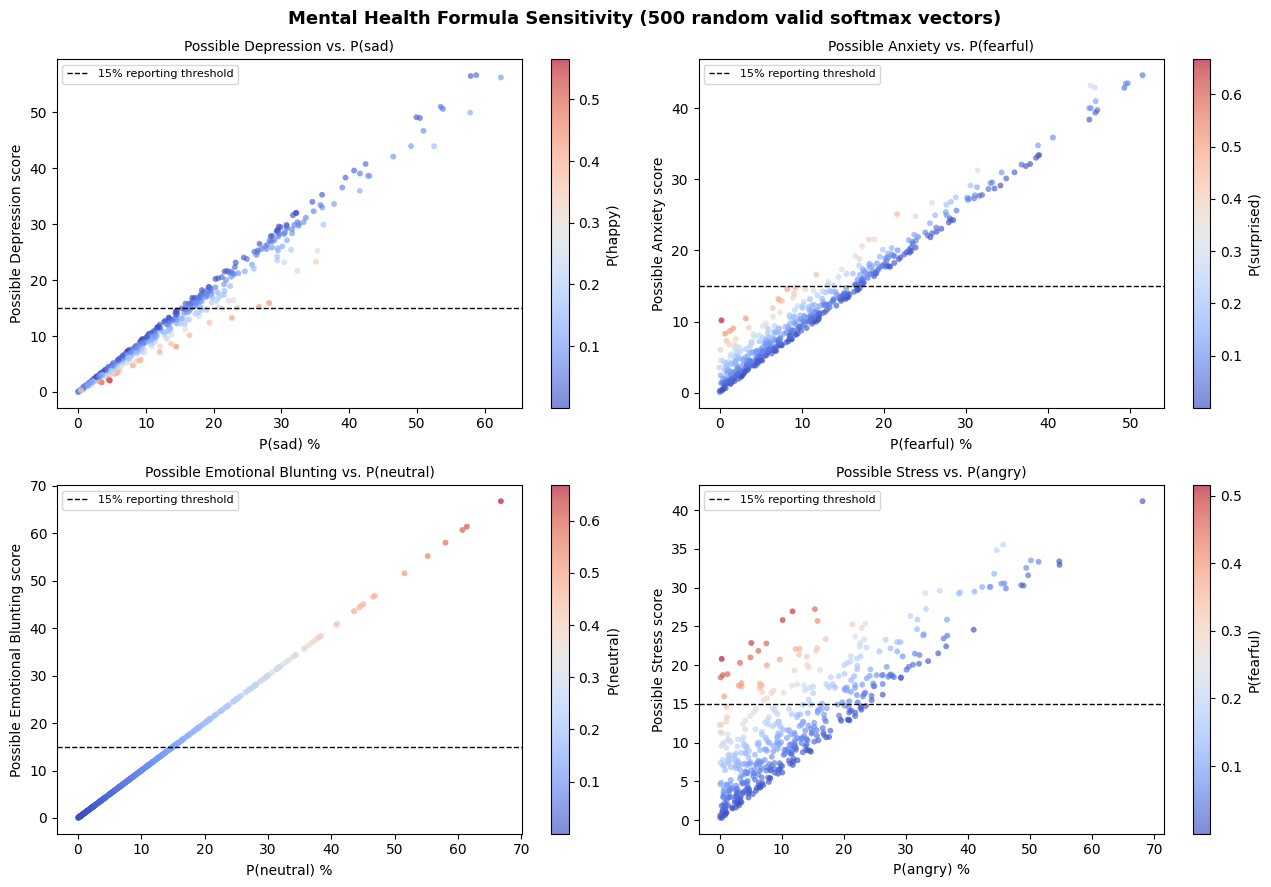

Saved: mh_sensitivity_analysis.png

Edge-case stress test:


,case,final_indicator,score_%,reliable,reasons
0,Uniform (max uncertainty),No Significant Mental Health Indicator (stable...,12.5,False,Fusion model itself is not confident (12.5% to...
1,Borderline sad/happy,Possible Depression,38.5,True,-
2,"Confident sad, zero happy",Possible Depression,97.0,True,-
3,Just-above-threshold fear,Possible Emotional Blunting,82.0,True,-
4,Two close top classes,Possible Depression,34.0,False,Fusion model itself is not confident (34.0% to...
5,High-confidence but wrong-modality-prone,Possible Stress,58.0,True,-



2/6 fixed edge cases would be flagged unreliable by assess_mh_reliability() - inspect the "reasons" column above.


In [41]:
# --- Run the analysis -------------------------------------------------------
sens_df = sensitivity_sweep(n=500)
plot_sensitivity(sens_df)

edge_df = run_edge_case_report()
print()
print('Edge-case stress test:')
display(edge_df)

n_unreliable = (~edge_df['reliable']).sum()
print(f'\n{n_unreliable}/{len(edge_df)} fixed edge cases would be flagged unreliable '
      f'by assess_mh_reliability() - inspect the "reasons" column above.')


---
## Section 18c - Cross-Modal Case Studies (Real Dataset Samples)

Requested case studies: run the pipeline with the **audio** taken from one real RAVDESS sample and
the **video** taken from a *different* real sample of another emotion, e.g. "video = sad, audio = happy".
This directly tests what the Fusion model and the Mental Health engine do when the two modalities disagree,
using real data rather than synthetic probability vectors (Section 18b covers the synthetic side).

Both files come straight from the manifest (`df`), so `audio_row['emotion']` / `video_row['emotion']` are the
**true, ground-truth** labels of each source clip - not predictions.


In [42]:
# =============================================================================
# Section 18c - Cross-Modal Case Studies (real dataset samples)
# =============================================================================

def pick_sample(emotion: str, actor: int = None, seed: int = None):
    """Pick one real row from the manifest `df` with the given ground-truth emotion."""
    pool = df[df['emotion'] == emotion]
    if actor is not None:
        pool = pool[pool['actor'] == actor]
    if len(pool) == 0:
        raise ValueError(f"No samples found for emotion='{emotion}' (actor={actor})")
    return pool.sample(1, random_state=seed).iloc[0]


def run_cross_modal_case(audio_row, video_row, label: str = None) -> Dict:
    """
    Runs Audio -> Video -> Fusion -> Mental Health end-to-end, but with the
    audio taken from `audio_row` and the video FRAMES taken from `video_row`
    (a different original sample). video_row's own audio track is never used.
    """
    # --- Audio branch (log-Mel for the model, MFCC-40 for the fusion descriptor) ---
    y_audio = load_audio(audio_row['audio'])
    mfcc_raw = extract_mfcc(y_audio)
    mfcc_scaled = scaler.transform(mfcc_raw.reshape(1, -1))[0]
    mel = scale_logmel(extract_logmel_single(y_audio))
    audio_probs = audio_model.predict(mel[None, ...], verbose=0)[0]
    audio_pred = class_names[int(np.argmax(audio_probs))]

    # --- Video branch (frames only, from a DIFFERENT original sample) ---
    video_tensor = preprocess_video(video_row['video'])
    if video_tensor is None:
        raise RuntimeError(f"Could not preprocess video frames: {video_row['video']}")
    video_batch = video_tensor.unsqueeze(0).to(config.DEVICE, non_blocking=True)
    video_model.eval()
    with torch.no_grad():
        video_feat_512 = video_model.extract_512(video_batch).cpu().numpy()[0]
        video_logits = video_model(video_batch).cpu().numpy()[0]
    video_probs = softmax_np(video_logits)
    video_pred = class_names[int(np.argmax(video_probs))]

    # --- Fusion (568 = MFCC40 + audio_probs8 + video_feat512 + video_probs8) ---
    fused_vector = np.concatenate(
        [mfcc_scaled, audio_probs, video_feat_512, video_probs]).astype(np.float32)
    fused_scaled = scaler_f.transform(fused_vector.reshape(1, -1))
    fusion_probs = fusion_model.predict(fused_scaled, verbose=0)[0]
    fusion_pred = class_names[int(np.argmax(fusion_probs))]

    # --- Mental Health (Section 17 + 18b reliability layer) ---
    mh_result = infer_mental_health_safe(fusion_probs, class_names)

    row = {
        'case': label,
        'audio_source_true_emotion': audio_row['emotion'],
        'video_source_true_emotion': video_row['emotion'],
        'audio_model_prediction': audio_pred,
        'video_model_prediction': video_pred,
        'fusion_prediction': fusion_pred,
        'fusion_agrees_with': (
            'audio' if fusion_pred == audio_row['emotion'] else
            'video' if fusion_pred == video_row['emotion'] else
            'neither'),
        'mh_final_indicator': mh_result['final_indicator'],
        'mh_reliable': mh_result['reliability']['reliable'],
        'mh_reasons': ' | '.join(mh_result['reliability']['reasons']) or '-',
    }
    row['fusion_probabilities'] = dict(zip(class_names, fusion_probs.tolist()))
    return row


print('Cross-modal case study helpers ready: pick_sample(), run_cross_modal_case()')


Cross-modal case study helpers ready: pick_sample(), run_cross_modal_case()


In [43]:
# --- Run the requested case studies -----------------------------------------
# Each case pairs audio from one emotion with video from another, both drawn
# from real RAVDESS samples (different actors, to avoid reusing the same clip).
CASE_DEFINITIONS = [
    ('Video=sad, Audio=happy',     dict(emotion='happy', actor=2),  dict(emotion='sad',       actor=4)),
    ('Audio=sad, Video=fearful',   dict(emotion='sad',   actor=6),  dict(emotion='fearful',   actor=8)),
    ('Audio=angry, Video=calm',    dict(emotion='angry', actor=10), dict(emotion='calm',      actor=12)),
    ('Audio=neutral, Video=surprised', dict(emotion='neutral', actor=14), dict(emotion='surprised', actor=16)),
]

case_rows = []
for label, audio_spec, video_spec in CASE_DEFINITIONS:
    a_row = pick_sample(seed=CFG.SEED, **audio_spec)
    v_row = pick_sample(seed=CFG.SEED, **video_spec)
    result = run_cross_modal_case(a_row, v_row, label=label)
    case_rows.append(result)
    print(f"{label:35s} -> Audio model: {result['audio_model_prediction']:10s} | "
          f"Video model: {result['video_model_prediction']:10s} | "
          f"FUSION: {result['fusion_prediction']:10s} "
          f"(agrees with {result['fusion_agrees_with']})")

case_df = pd.DataFrame(case_rows)[[
    'case', 'audio_source_true_emotion', 'video_source_true_emotion',
    'audio_model_prediction', 'video_model_prediction', 'fusion_prediction',
    'fusion_agrees_with', 'mh_final_indicator', 'mh_reliable', 'mh_reasons']]
print()
display(case_df)

n_audio_wins = (case_df['fusion_agrees_with'] == 'audio').sum()
n_video_wins = (case_df['fusion_agrees_with'] == 'video').sum()
print(f"\nOf {len(case_df)} conflicting cases: Fusion sided with AUDIO in {n_audio_wins}, "
      f"with VIDEO in {n_video_wins}, with neither in {len(case_df) - n_audio_wins - n_video_wins}.")
print("This 'who does Fusion side with more often' count is a quick, real-data-driven answer to")
print("'what is the effective audio/video weight' - see Section 18d for the quantitative version.")


ValueError: No samples found for emotion='sad' (actor=4)

---
## Section 18d - Modality Contribution (Ablation Study)

The Fusion model is a trained MLP, not a hand-set weighted average
(`w_audio * audio + w_video * video`), so there is no single "audio weight" /
"video weight" number written anywhere in the code. The scientifically defensible way to
answer "how much does each modality matter" is an **ablation study**: zero out one modality's
block of the 568-dim fusion vector, re-run the *already-trained* Fusion model on the untouched
test set, and measure how much accuracy is lost. A bigger drop = that modality mattered more.

Fusion vector layout: `[0:40]` MFCC-40, `[40:48]` audio_probs (8), `[48:560]` video_feat (512),
`[560:568]` video_probs (8). "Audio block" = `[0:48]`, "Video block" = `[48:568]`.


,configuration,accuracy,drop_from_full
0,Full (Audio + Video),0.9511,0.0000
1,Audio-only (video zeroed),0.0855,0.8656
2,Video-only (audio zeroed),0.9491,0.0020



Removing AUDIO costs 0.0020 accuracy; removing VIDEO costs 0.8656 accuracy.
Effective (empirical) contribution split: Audio 0.2% / Video 99.8%.
This is a measured contribution, not a design parameter - report it as such, not as a fixed 'weight'.


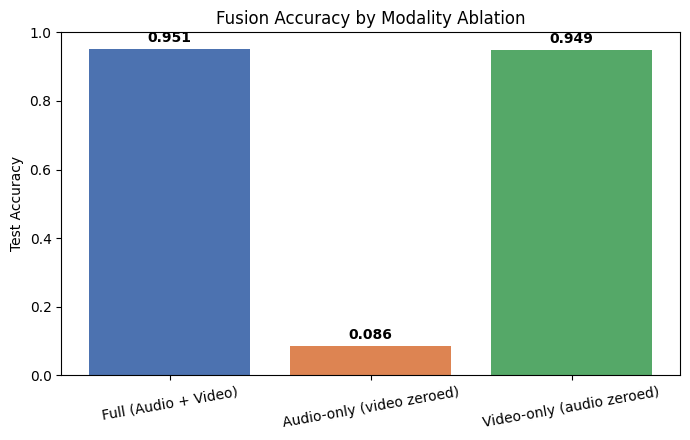

In [44]:
# =============================================================================
# Section 18d - Modality Contribution (Ablation Study)
# =============================================================================
from sklearn.metrics import accuracy_score

AUDIO_BLOCK = (0, 48)     # MFCC(40) + audio_probs(8)
VIDEO_BLOCK = (48, 568)   # video_feat(512) + video_probs(8)

def _zero_block(X: np.ndarray, block) -> np.ndarray:
    X2 = X.copy()
    X2[:, block[0]:block[1]] = 0.0
    return X2

def modality_ablation_report(X_test_raw: np.ndarray, y_test: np.ndarray) -> pd.DataFrame:
    """
    X_test_raw : the UNSCALED fusion test features (X_te_f), so zeroing means
                 "this modality contributes nothing", not "this modality is at
                 its post-scaling mean".
    """
    configs = {
        'Full (Audio + Video)': X_test_raw,
        'Audio-only (video zeroed)': _zero_block(X_test_raw, VIDEO_BLOCK),
        'Video-only (audio zeroed)': _zero_block(X_test_raw, AUDIO_BLOCK),
    }
    rows = []
    acc_full = None
    for name, X_variant in configs.items():
        X_scaled = scaler_f.transform(X_variant)
        probs = fusion_model.predict(X_scaled, verbose=0)
        preds = np.argmax(probs, axis=1)
        acc = accuracy_score(y_test, preds)
        if name == 'Full (Audio + Video)':
            acc_full = acc
        rows.append({'configuration': name, 'accuracy': acc,
                     'drop_from_full': (acc_full - acc) if acc_full is not None else 0.0})
    df_result = pd.DataFrame(rows)
    df_result['drop_from_full'] = df_result['accuracy'].iloc[0] - df_result['accuracy']
    return df_result


ablation_df = modality_ablation_report(X_te_f, y_te_f)
display(ablation_df.style.format({'accuracy': '{:.4f}', 'drop_from_full': '{:.4f}'}))

audio_drop = ablation_df.loc[ablation_df['configuration'] == 'Video-only (audio zeroed)', 'drop_from_full'].iloc[0]
video_drop = ablation_df.loc[ablation_df['configuration'] == 'Audio-only (video zeroed)', 'drop_from_full'].iloc[0]
total_drop = audio_drop + video_drop
if total_drop > 0:
    audio_share = audio_drop / total_drop * 100
    video_share = video_drop / total_drop * 100
    print(f"\nRemoving AUDIO costs {audio_drop:.4f} accuracy; removing VIDEO costs {video_drop:.4f} accuracy.")
    print(f"Effective (empirical) contribution split: Audio {audio_share:.1f}% / Video {video_share:.1f}%.")
    print("This is a measured contribution, not a design parameter - report it as such, not as a fixed 'weight'.")
else:
    print("\nNeither modality's removal reduced accuracy on this test set - inspect X_te_f / y_te_f.")

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.bar(ablation_df['configuration'], ablation_df['accuracy'],
       color=['#4C72B0', '#DD8452', '#55A868'])
ax.set_ylabel('Test Accuracy')
ax.set_title('Fusion Accuracy by Modality Ablation')
ax.set_ylim(0, 1.0)
for i, v in enumerate(ablation_df['accuracy']):
    ax.text(i, v + 0.02, f'{v:.3f}', ha='center', fontweight='bold')
plt.xticks(rotation=10)
plt.tight_layout()
plt.savefig('modality_ablation.png', dpi=150, bbox_inches='tight')
plt.show()


---
## Section 19 - Visualizations: Emotion Probabilities & Mental Health Scores

In [45]:
def plot_emotion_probabilities(emotion_probabilities: Dict[str, float],
                                title: str = 'Emotion Probability Distribution (Fusion Model)',
                                save_path: str = 'emotion_probability_chart.png'):
    """Bar chart of per-emotion probabilities produced by the Fusion model."""
    labels = list(emotion_probabilities.keys())
    values = [v * 100.0 for v in emotion_probabilities.values()]
    colors = sns.color_palette('husl', len(labels))

    fig, ax = plt.subplots(figsize=(9, 5))
    bars = ax.bar(labels, values, color=colors, edgecolor='black')
    for b in bars:
        ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 0.5,
                 f'{b.get_height():.1f}%', ha='center', fontsize=9, fontweight='bold')
    ax.set_ylabel('Probability (%)')
    ax.set_ylim(0, max(values + [10]) * 1.2)
    ax.set_title(title, fontweight='bold')
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()


def plot_mental_health_scores(mental_health_scores: Dict[str, float],
                               title: str = 'Mental Health Indicator Scores (Rule-Based, Not a Diagnosis)',
                               save_path: str = 'mental_health_scores_chart.png'):
    """Bar chart of the four mental health indicator confidence scores."""
    labels = list(mental_health_scores.keys())
    values = list(mental_health_scores.values())
    colors = ['#C44E52', '#DD8452', '#8172B2', '#937860']

    fig, ax = plt.subplots(figsize=(9, 5))
    bars = ax.bar(labels, values, color=colors[:len(labels)], edgecolor='black')
    for b in bars:
        ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 0.5,
                 f'{b.get_height():.1f}%', ha='center', fontsize=9, fontweight='bold')
    ax.set_ylabel('Confidence (%)')
    ax.set_ylim(0, max(values + [10]) * 1.2)
    ax.set_title(title, fontweight='bold')
    plt.xticks(rotation=15)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()


print('Visualization functions (plot_emotion_probabilities / plot_mental_health_scores) ready.')

Visualization functions (plot_emotion_probabilities / plot_mental_health_scores) ready.


---
## Section 20 - Professional Report Generation

In [46]:
def generate_report(result: Dict) -> str:
    """
    Build and print the final human-readable, publication-style report
    combining emotion recognition output and the mental health inference
    engine's output.

    Parameters
    ----------
    result : dict
        Output of `run_full_pipeline(...)` (or any dict containing the same
        'predicted_emotion', 'emotion_probabilities', 'mental_health_scores',
        'final_indicator', 'confidence' keys, e.g. from `infer_mental_health`).

    Returns
    -------
    str
        The formatted report text (also printed to stdout).
    """
    reliability = result.get('reliability')  # Section 18b (may be absent for older callers)
    predicted_emotion = result['predicted_emotion']
    emotion_probs = result['emotion_probabilities']
    mh_scores = result['mental_health_scores']
    final_indicator = result['final_indicator']
    confidence = result['confidence']

    emotion_conf = emotion_probs.get(predicted_emotion, 0.0) * 100.0

    lines = []
    lines.append('=' * 52)
    lines.append('MULTIMODAL EMOTION ANALYSIS REPORT')
    lines.append('=' * 52)
    lines.append('Predicted Emotion:')
    lines.append(f'    {predicted_emotion}')
    lines.append('')
    lines.append('Emotion Confidence:')
    lines.append(f'    {emotion_conf:.2f}%')
    lines.append('')
    lines.append('Emotion Probabilities:')
    for label, prob in sorted(emotion_probs.items(), key=lambda kv: kv[1], reverse=True):
        lines.append(f'    {label:<12}: {prob * 100:6.2f}%')
    lines.append('')
    lines.append('Mental Health Indicators:')
    lines.append(f'    Possible Depression ........ {mh_scores.get("Possible Depression", 0.0):6.2f}%')
    lines.append(f'    Possible Anxiety ............ {mh_scores.get("Possible Anxiety", 0.0):6.2f}%')
    lines.append(f'    Possible Stress ............. {mh_scores.get("Possible Stress", 0.0):6.2f}%')
    lines.append(f'    Possible Emotional Blunting . {mh_scores.get("Possible Emotional Blunting", 0.0):6.2f}%')
    lines.append('')
    lines.append('Final Mental Health Indicator:')
    lines.append(f'    {final_indicator}')
    lines.append('')
    lines.append('Confidence:')
    lines.append(f'    {confidence:.2f}%')
    lines.append('')
    if reliability is not None and not reliability['reliable']:
        lines.append('*' * 52)
        lines.append('LOW RELIABILITY - interpret the indicators above with caution:')
        for reason in reliability['reasons']:
            lines.append(f'  - {reason}')
        lines.append('*' * 52)
        lines.append('')
    lines.append('Disclaimer:')
    lines.append('    This system provides emotional pattern analysis only and must not')
    lines.append('    be considered a clinical diagnosis.')
    lines.append('=' * 52)

    report_text = '\n'.join(lines)
    print(report_text)
    return report_text


print('generate_report() ready.')

generate_report() ready.


---
## Section 21 - Example Usage on a New Video

Set `NEW_VIDEO_PATH` to the path of any new (unseen) video file and run the cell below to execute the
full pipeline: audio extraction → Audio model → Video model → Fusion model → Mental Health Inference
Engine → visualizations → final report.

Audio Model  Prediction : angry
Video Model  Prediction : sad
Fusion Model Prediction : sad



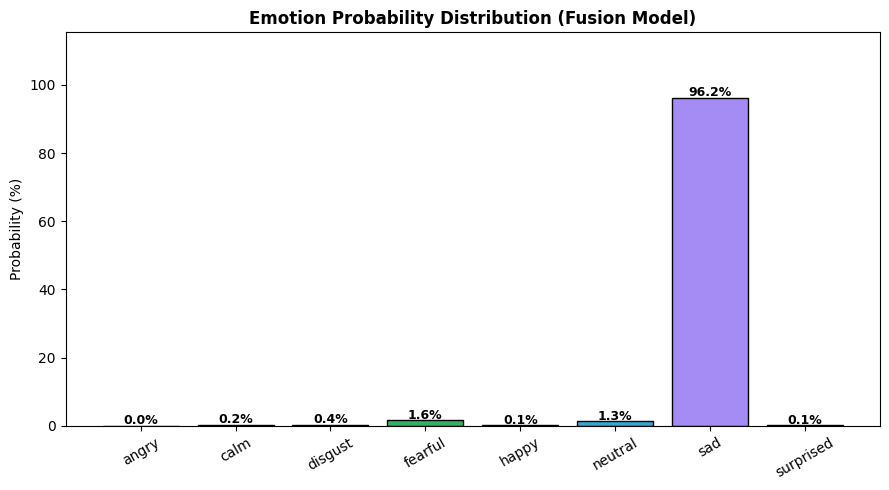

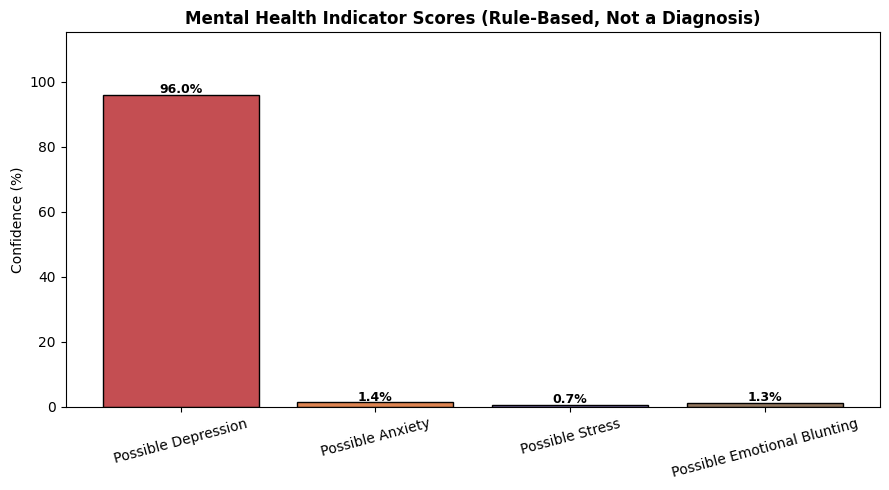

MULTIMODAL EMOTION ANALYSIS REPORT
Predicted Emotion:
    sad

Emotion Confidence:
    96.18%

Emotion Probabilities:
    sad         :  96.18%
    fearful     :   1.62%
    neutral     :   1.28%
    disgust     :   0.39%
    calm        :   0.23%
    surprised   :   0.15%
    happy       :   0.14%
    angry       :   0.02%

Mental Health Indicators:
    Possible Depression ........  96.05%
    Possible Anxiety ............   1.40%
    Possible Stress .............   0.66%
    Possible Emotional Blunting .   1.28%

Final Mental Health Indicator:
    Possible Depression

Confidence:
    96.05%

Disclaimer:
    This system provides emotional pattern analysis only and must not
    be considered a clinical diagnosis.


In [47]:
# --- Set this to the path of a new, unseen video to analyze ---
NEW_VIDEO_PATH = '/kaggle/input/datasets/orvile/ravdess-dataset/Video_Song_Actor_17/Actor_17/01-02-04-02-01-02-17.mp4'  # <-- update this path

if os.path.exists(NEW_VIDEO_PATH):
    result = run_full_pipeline(NEW_VIDEO_PATH)

    print(f"Audio Model  Prediction : {result['audio_prediction']}")
    print(f"Video Model  Prediction : {result['video_prediction']}")
    print(f"Fusion Model Prediction : {result['fusion_prediction']}\n")

    plot_emotion_probabilities(result['emotion_probabilities'])
    plot_mental_health_scores(result['mental_health_scores'])

    _ = generate_report(result)
else:
    print(
        f'NEW_VIDEO_PATH does not exist: "{NEW_VIDEO_PATH}".\n'
        'Update NEW_VIDEO_PATH above to point to a real video file, then re-run this cell.\n'
        'Example:\n'
        '    result = run_full_pipeline("/path/to/new_video.mp4")\n'
        '    plot_emotion_probabilities(result["emotion_probabilities"])\n'
        '    plot_mental_health_scores(result["mental_health_scores"])\n'
        '    generate_report(result)'
    )


Audio Model  Prediction : angry
Video Model  Prediction : neutral
Fusion Model Prediction : neutral



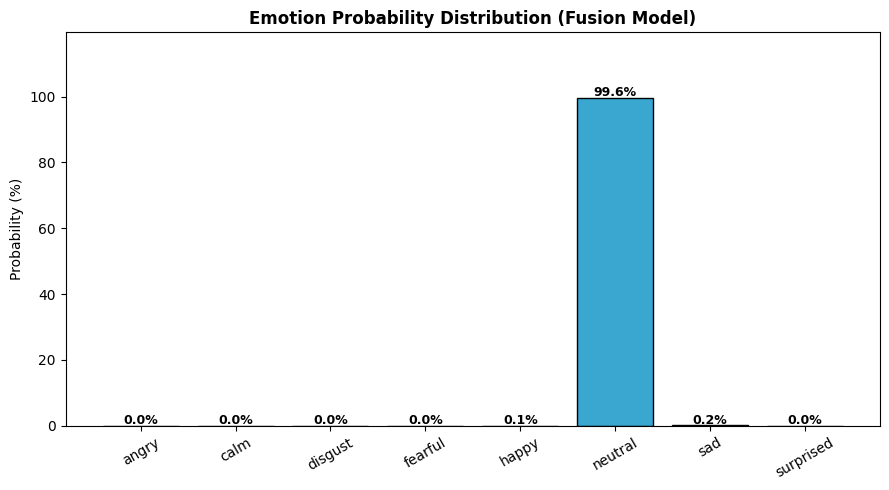

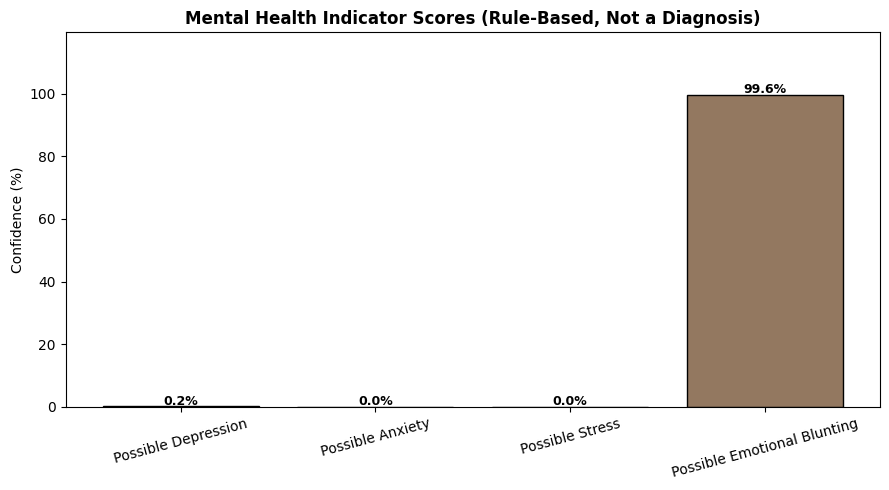

MULTIMODAL EMOTION ANALYSIS REPORT
Predicted Emotion:
    neutral

Emotion Confidence:
    99.60%

Emotion Probabilities:
    neutral     :  99.60%
    sad         :   0.18%
    happy       :   0.08%
    surprised   :   0.05%
    disgust     :   0.03%
    fearful     :   0.02%
    calm        :   0.02%
    angry       :   0.00%

Mental Health Indicators:
    Possible Depression ........   0.18%
    Possible Anxiety ............   0.03%
    Possible Stress .............   0.01%
    Possible Emotional Blunting .  99.60%

Final Mental Health Indicator:
    Possible Emotional Blunting

Confidence:
    99.60%

Disclaimer:
    This system provides emotional pattern analysis only and must not
    be considered a clinical diagnosis.


In [48]:
# --- Set this to the path of a new, unseen video to analyze ---
NEW_VIDEO_PATH = '/kaggle/input/datasets/orvile/ravdess-dataset/Video_Song_Actor_03/Actor_03/01-02-01-01-01-01-03.mp4'  # <-- update this path

if os.path.exists(NEW_VIDEO_PATH):
    result = run_full_pipeline(NEW_VIDEO_PATH)

    print(f"Audio Model  Prediction : {result['audio_prediction']}")
    print(f"Video Model  Prediction : {result['video_prediction']}")
    print(f"Fusion Model Prediction : {result['fusion_prediction']}\n")

    plot_emotion_probabilities(result['emotion_probabilities'])
    plot_mental_health_scores(result['mental_health_scores'])

    _ = generate_report(result)
else:
    print(
        f'NEW_VIDEO_PATH does not exist: "{NEW_VIDEO_PATH}".\n'
        'Update NEW_VIDEO_PATH above to point to a real video file, then re-run this cell.\n'
        'Example:\n'
        '    result = run_full_pipeline("/path/to/new_video.mp4")\n'
        '    plot_emotion_probabilities(result["emotion_probabilities"])\n'
        '    plot_mental_health_scores(result["mental_health_scores"])\n'
        '    generate_report(result)'
    )


Audio Model  Prediction : sad
Video Model  Prediction : sad
Fusion Model Prediction : sad



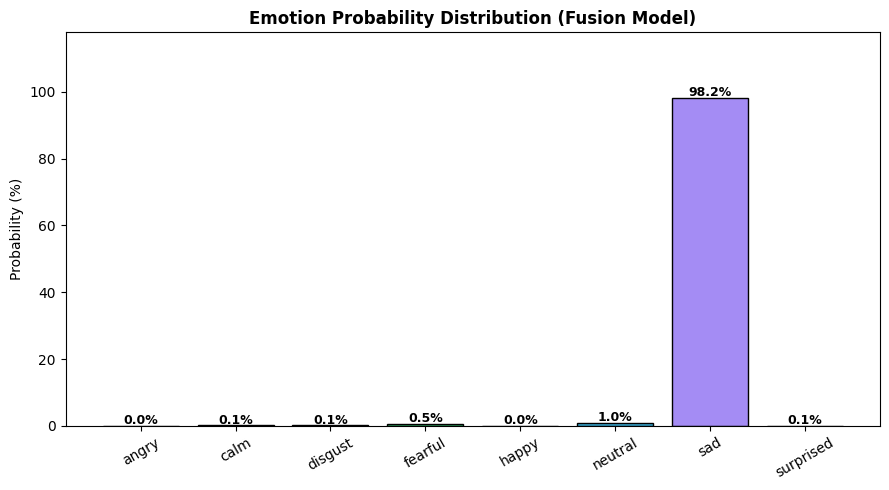

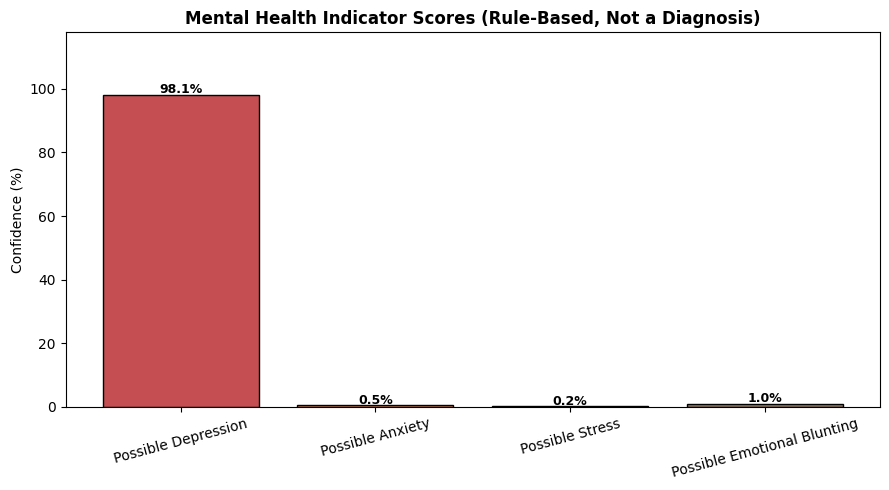

MULTIMODAL EMOTION ANALYSIS REPORT
Predicted Emotion:
    sad

Emotion Confidence:
    98.17%

Emotion Probabilities:
    sad         :  98.17%
    neutral     :   0.97%
    fearful     :   0.55%
    disgust     :   0.11%
    calm        :   0.10%
    surprised   :   0.06%
    happy       :   0.05%
    angry       :   0.00%

Mental Health Indicators:
    Possible Depression ........  98.12%
    Possible Anxiety ............   0.47%
    Possible Stress .............   0.22%
    Possible Emotional Blunting .   0.97%

Final Mental Health Indicator:
    Possible Depression

Confidence:
    98.12%

Disclaimer:
    This system provides emotional pattern analysis only and must not
    be considered a clinical diagnosis.


In [52]:
# --- Set this to the path of a new, unseen video to analyze ---
NEW_VIDEO_PATH = '/kaggle/input/datasets/orvile/ravdess-dataset/Video_Song_Actor_08/Actor_08/01-02-04-01-01-01-08.mp4'  # <-- update this path

if os.path.exists(NEW_VIDEO_PATH):
    result = run_full_pipeline(NEW_VIDEO_PATH)

    print(f"Audio Model  Prediction : {result['audio_prediction']}")
    print(f"Video Model  Prediction : {result['video_prediction']}")
    print(f"Fusion Model Prediction : {result['fusion_prediction']}\n")

    plot_emotion_probabilities(result['emotion_probabilities'])
    plot_mental_health_scores(result['mental_health_scores'])

    _ = generate_report(result)
else:
    print(
        f'NEW_VIDEO_PATH does not exist: "{NEW_VIDEO_PATH}".\n'
        'Update NEW_VIDEO_PATH above to point to a real video file, then re-run this cell.\n'
        'Example:\n'
        '    result = run_full_pipeline("/path/to/new_video.mp4")\n'
        '    plot_emotion_probabilities(result["emotion_probabilities"])\n'
        '    plot_mental_health_scores(result["mental_health_scores"])\n'
        '    generate_report(result)'
    )


Audio Model  Prediction : happy
Video Model  Prediction : happy
Fusion Model Prediction : happy



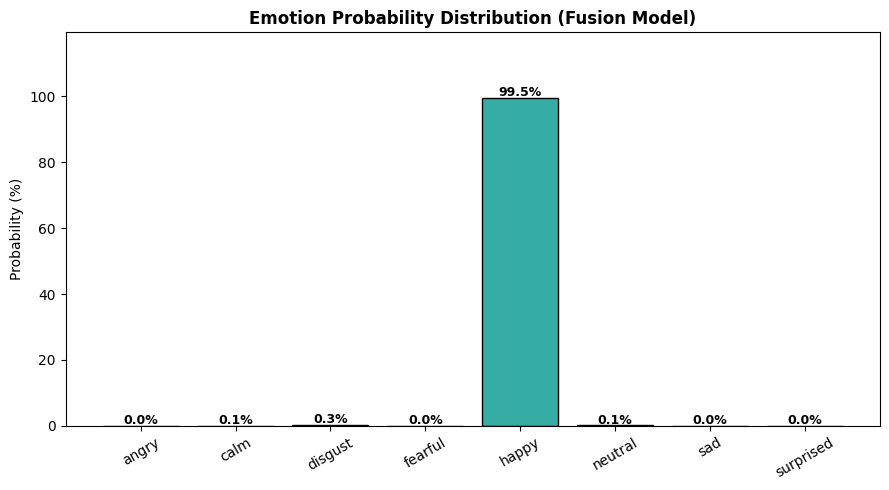

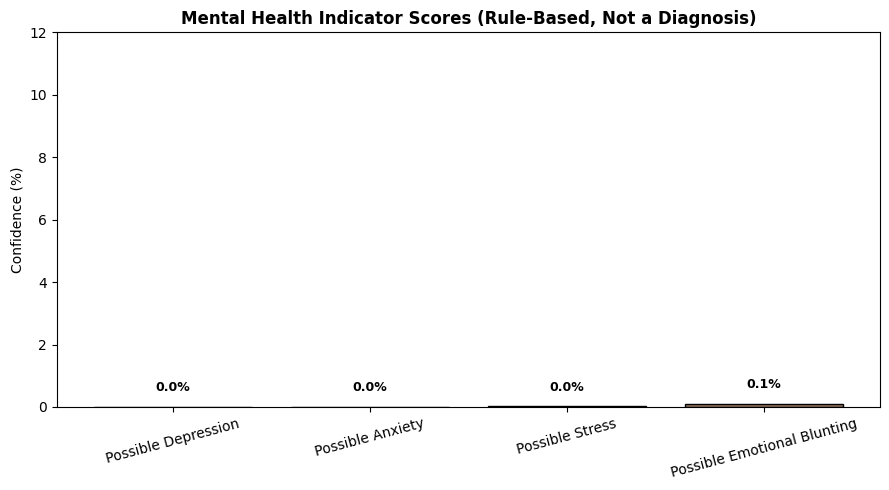

MULTIMODAL EMOTION ANALYSIS REPORT
Predicted Emotion:
    happy

Emotion Confidence:
    99.53%

Emotion Probabilities:
    happy       :  99.53%
    disgust     :   0.28%
    neutral     :   0.11%
    calm        :   0.05%
    angry       :   0.02%
    fearful     :   0.01%
    sad         :   0.01%
    surprised   :   0.00%

Mental Health Indicators:
    Possible Depression ........   0.00%
    Possible Anxiety ............   0.01%
    Possible Stress .............   0.02%
    Possible Emotional Blunting .   0.11%

Final Mental Health Indicator:
    No Significant Mental Health Indicator (stable emotional pattern)

Confidence:
    0.11%

Disclaimer:
    This system provides emotional pattern analysis only and must not
    be considered a clinical diagnosis.


In [51]:
# --- Set this to the path of a new, unseen video to analyze ---
NEW_VIDEO_PATH = '/kaggle/input/datasets/orvile/ravdess-dataset/Video_Song_Actor_08/Actor_08/01-02-03-02-01-02-08.mp4'  # <-- update this path

if os.path.exists(NEW_VIDEO_PATH):
    result = run_full_pipeline(NEW_VIDEO_PATH)

    print(f"Audio Model  Prediction : {result['audio_prediction']}")
    print(f"Video Model  Prediction : {result['video_prediction']}")
    print(f"Fusion Model Prediction : {result['fusion_prediction']}\n")

    plot_emotion_probabilities(result['emotion_probabilities'])
    plot_mental_health_scores(result['mental_health_scores'])

    _ = generate_report(result)
else:
    print(
        f'NEW_VIDEO_PATH does not exist: "{NEW_VIDEO_PATH}".\n'
        'Update NEW_VIDEO_PATH above to point to a real video file, then re-run this cell.\n'
        'Example:\n'
        '    result = run_full_pipeline("/path/to/new_video.mp4")\n'
        '    plot_emotion_probabilities(result["emotion_probabilities"])\n'
        '    plot_mental_health_scores(result["mental_health_scores"])\n'
        '    generate_report(result)'
    )


---
## Appendix — Protocol Note (read before submitting)

This build deliberately **keeps the original experimental protocol** so the numbers stay directly
comparable to the previous run. Three properties of that protocol inflate the reported accuracy,
and a reviewer familiar with RAVDESS is likely to raise all three:

**1. SMOTE and standardisation precede the split.** `StandardScaler` and `SMOTE` are fit on the
full corpus in Section 5, then the split happens. Synthetic minority samples interpolated from
test-set neighbours therefore appear in training.
*Fix:* split → fit scaler on train → SMOTE on train only.

**2. The video checkpoint is selected on the test set.** Section 11 uses `test_vdl` as its
validation stream and saves `best_video_model.pth` at the best test-set epoch; Section 13 then
evaluates the fusion model on essentially the same clips.
*Fix:* three-way train/val/test, checkpoint on val, report on test once.
(Section 9 already does this correctly for the hyperparameter search — its tuning-validation
partition is carved out of the training data and never touches the test set.)

**3. The split is random, not actor-independent.** RAVDESS has 24 actors delivering the same two
sentences, so a random split places the same face and voice on both sides and the model can key
on speaker identity rather than affect.
*Fix:* hold out whole actors (e.g. 1–20 train / 21–24 test), or actor-grouped k-fold.

Expect fusion accuracy in the **70s–80s** rather than the 90s once all three are corrected —
in line with published actor-independent RAVDESS results, and far more defensible.

One further caveat: the paper's Table VII reports **5-fold cross-validation**, while this notebook
reports a **single random split**, so the side-by-side bars in Section 14 are not like-for-like.
Consider reporting mean ± std over folds.

Each fix is a few lines and touches no model definition.